In [218]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("file:./mlruns")   # local folder in your project
mlflow.set_experiment("Customer-Churn-Phase2")


<Experiment: artifact_location='file:///C:/Users/MSI/mlruns/874381330656958606', creation_time=1766181308295, experiment_id='874381330656958606', last_update_time=1766181308295, lifecycle_stage='active', name='Customer-Churn-Phase2', tags={}>

In [222]:
import os, mlflow

print("Current working directory (CWD):")
print(os.getcwd())

print("\nMLflow tracking URI:")
print(mlflow.get_tracking_uri())

print("\nAbsolute path where MLflow writes files:")
if mlflow.get_tracking_uri().startswith("file:"):
    print(os.path.abspath("mlruns"))
elif mlflow.get_tracking_uri().startswith("sqlite"):
    print(os.path.abspath("mlflow.db"))


Current working directory (CWD):
C:\Users\MSI

MLflow tracking URI:
file:./mlruns

Absolute path where MLflow writes files:
C:\Users\MSI\mlruns


In [116]:
!pip install mlxtend

INFO: pip is looking at multiple versions of contourpy to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 3.3 MB/s eta 0:00:01
   -------------------------------------- - 1.3/1.4 MB 3.7 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 2.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 4.2 MB/s eta 0:00:02
   --- ------------------------------------ 0.8/8.1 MB 3.7 MB/s eta 0:00:02
   --------- ------------------------------ 1.8/8.1 MB 3.1 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.1 MB 3.1 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.1 MB 3.2 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.1 MB 3.0 MB/s eta 0:00:02
   --------------------- -------

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\users\\msi\\anaconda3\\lib\\site-packages\\matplotlib\\mpl-data\\fonts\\ttf\\DejaVuSans.ttf'
Consider using the `--user` option or check the permissions.



In [5]:
%pip install mlflow


  Using cached mlflow-3.7.0-py3-none-any.whl.metadata (31 kB)
  Using cached mlflow_skinny-3.7.0-py3-none-any.whl.metadata (31 kB)
  Using cached mlflow_tracing-3.7.0-py3-none-any.whl.metadata (19 kB)
  Using cached flask_cors-6.0.2-py3-none-any.whl.metadata (5.3 kB)
  Using cached flask-3.1.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached alembic-1.17.2-py3-none-any.whl.metadata (7.2 kB)
  Using cached cryptography-46.0.3-cp38-abi3-win_amd64.whl.metadata (5.7 kB)
  Using cached docker-7.1.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached huey-2.5.5-py3-none-any.whl.metadata (4.8 kB)
  Using cached pyarrow-22.0.0-cp310-cp310-win_amd64.whl.metadata (3.3 kB)
  Using cached sqlalchemy-2.0.45-cp310-cp310-win_amd64.whl.metadata (9.8 kB)
  Using cached waitress-3.0.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached cachetools-6.2.4-py3-none-any.whl.metadata (5.6 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

In [1]:
import mlflow
print("MLflow:", mlflow.__version__)


MLflow: 3.7.0


In [7]:
import pandas as pd  
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [8]:
df = pd.read_csv(r"D:\Work\Machine Learning\phase2 dataset\customer_churn_business_dataset.csv")
df.head()

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


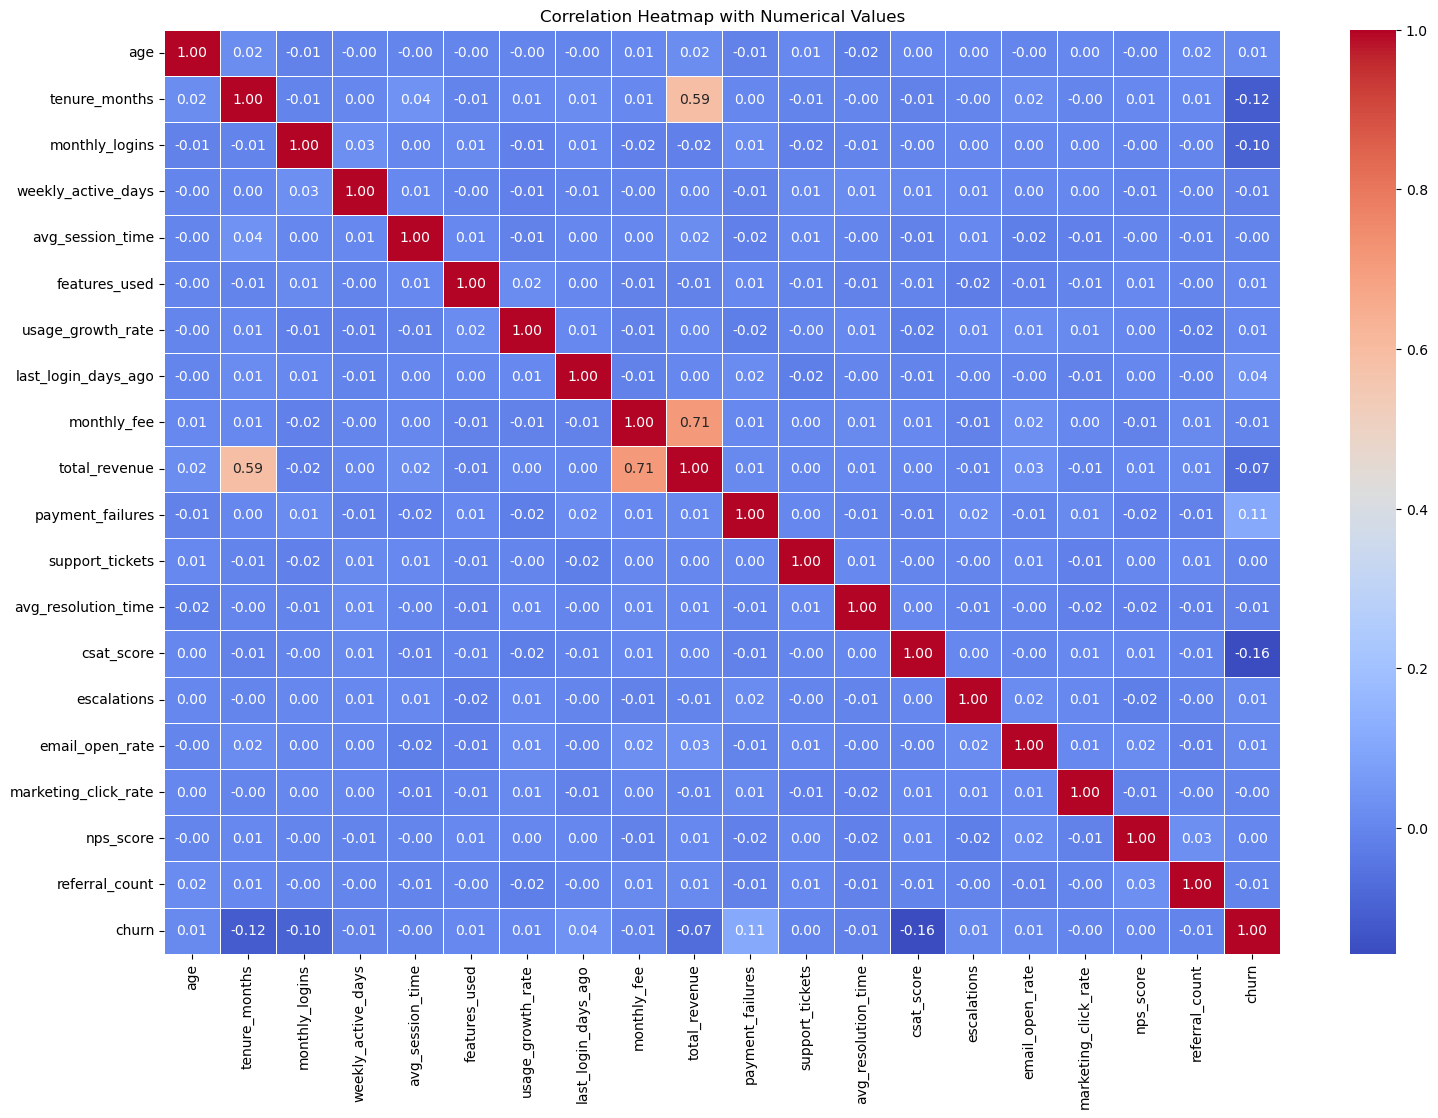

In [ ]:
#Check the relation between Features and Target
plt.figure(figsize=(18,12))

# Compute correlation matrix for numeric columns only
corr = df.corr(numeric_only=True)

# High values (pos/neg) indicate strong relationship between variables
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# Drop the ID column
df = df.drop(df.columns[[0]], axis=1)
df.head()

,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,weekly_active_days,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,7,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,5,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,Male,24,Germany,New York,SME,58,Web,Yearly,19,5,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,7,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,6,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


In [176]:
# Check distribution of target variable (churn)
df["churn"].value_counts()

churn
0    8979
1    1021
Name: count, dtype: int64

In [11]:
# Display summary statistics for numeric features
df.describe()

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,45.906100,30.155700,19.672000,3.479400,15.187890,4.990800,0.019423,9.505200,34.930000,1057.018000,0.501000,1.206600,23.953210,3.486700,0.294100,0.499610,0.253575,19.110500,0.9922,0.102100
std,16.420416,17.099517,9.838003,2.302283,6.830774,2.211607,0.149567,9.799417,23.785115,1020.148233,0.711934,1.104554,9.956999,0.978631,0.543171,0.231601,0.140532,38.936619,0.9939,0.302795
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-0.580000,0.000000,10.000000,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.100000,0.010000,-100.000000,0.0000,0.000000
25%,32.000000,16.000000,13.000000,1.000000,10.391645,3.000000,-0.080000,2.000000,20.000000,340.000000,0.000000,0.000000,17.082041,3.000000,0.000000,0.300000,0.130000,-7.000000,0.0000,0.000000
50%,46.000000,30.000000,20.000000,3.000000,15.161659,5.000000,0.020000,6.000000,30.000000,720.000000,0.000000,1.000000,23.950444,4.000000,0.000000,0.500000,0.250000,19.000000,1.0000,0.000000
75%,60.000000,45.000000,26.000000,5.000000,19.882034,6.000000,0.120000,13.000000,50.000000,1440.000000,1.000000,2.000000,30.758480,4.000000,1.000000,0.700000,0.380000,46.000000,2.0000,0.000000
max,74.000000,59.000000,54.000000,7.000000,41.996411,15.000000,0.540000,80.000000,100.000000,5900.000000,5.000000,7.000000,61.821878,5.000000,4.000000,0.900000,0.500000,100.000000,7.0000,1.000000


In [12]:
# Show dataset information (types, non-null counts)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  10000 non-null  object 
 1   age                     10000 non-null  int64  
 2   country                 10000 non-null  object 
 3   city                    10000 non-null  object 
 4   customer_segment        10000 non-null  object 
 5   tenure_months           10000 non-null  int64  
 6   signup_channel          10000 non-null  object 
 7   contract_type           10000 non-null  object 
 8   monthly_logins          10000 non-null  int64  
 9   weekly_active_days      10000 non-null  int64  
 10  avg_session_time        10000 non-null  float64
 11  features_used           10000 non-null  int64  
 12  usage_growth_rate       10000 non-null  float64
 13  last_login_days_ago     10000 non-null  int64  
 14  monthly_fee             10000 non-null 

In [13]:
# Check dataset dimensions
df.shape

(10000, 31)

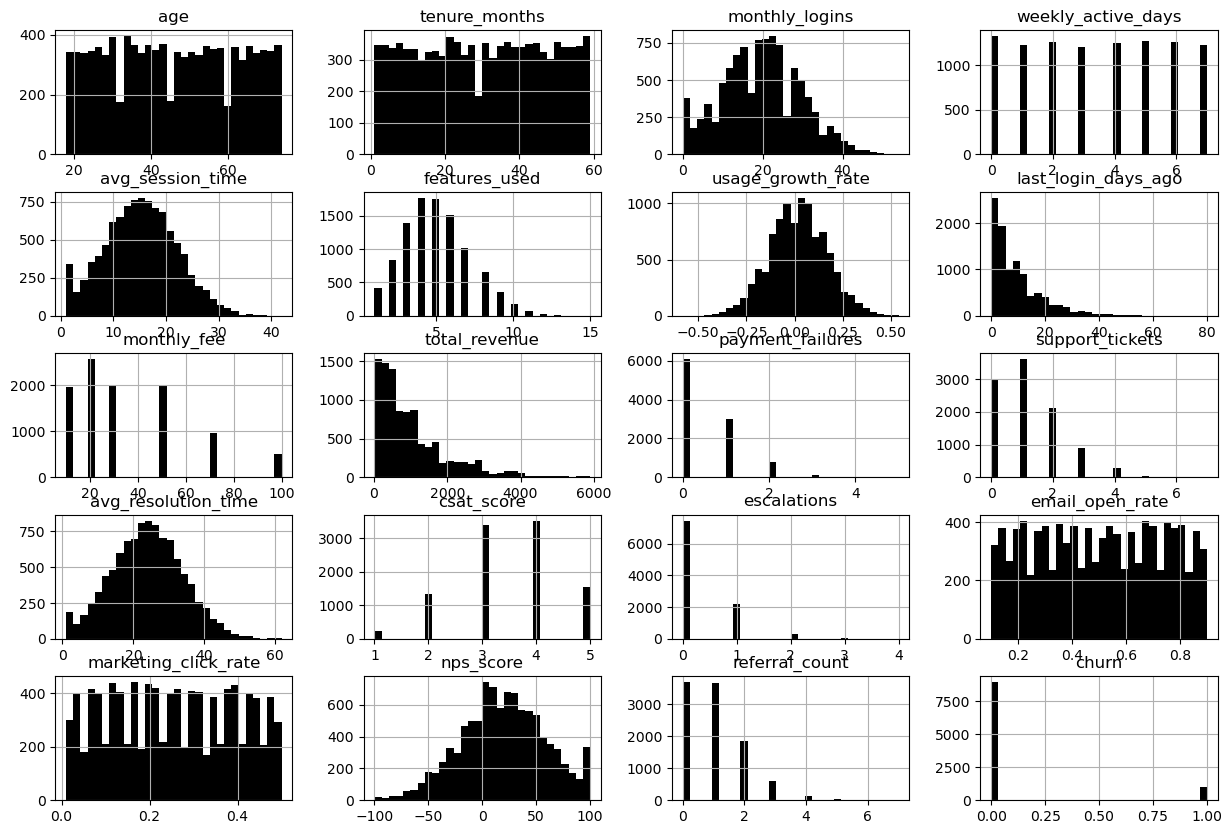

In [14]:
# Plot histograms for all numeric features
df.hist(color = "k",
        bins = 30,
        figsize = (15, 10))
plt.show()

In [15]:
# Check for missing values
df.isnull().sum()

gender                       0
age                          0
country                      0
city                         0
customer_segment             0
tenure_months                0
signup_channel               0
contract_type                0
monthly_logins               0
weekly_active_days           0
avg_session_time             0
features_used                0
usage_growth_rate            0
last_login_days_ago          0
monthly_fee                  0
total_revenue                0
payment_method               0
payment_failures             0
discount_applied             0
price_increase_last_3m       0
support_tickets              0
avg_resolution_time          0
complaint_type            2045
csat_score                   0
escalations                  0
email_open_rate              0
marketing_click_rate         0
nps_score                    0
survey_response              0
referral_count               0
churn                        0
dtype: int64

## Brief EDA

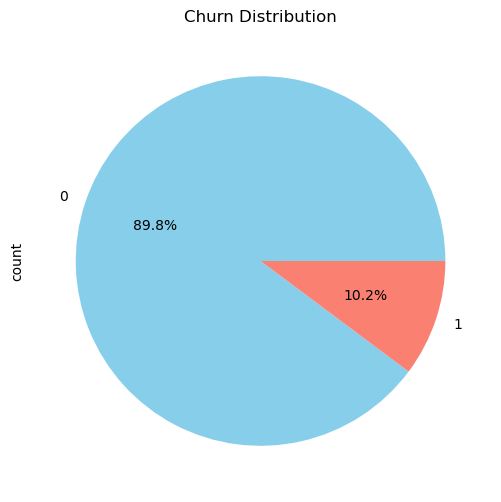

In [186]:
# 1. Target Distribution (Churn)
#It shows a huge Imbalance in the data leading to bias and high accuracy 
#The count of UnChurn (0) is 89.8% which is the most of the rows and Churn(1) is 10.2%.

plt.figure(figsize=(6,6))
df['churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'salmon'])
plt.title('Churn Distribution')
plt.show()

C:\Users\MSI\AppData\Local\Temp\ipykernel_18632\2618077628.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='monthly_fee', data=df, palette='Set2')


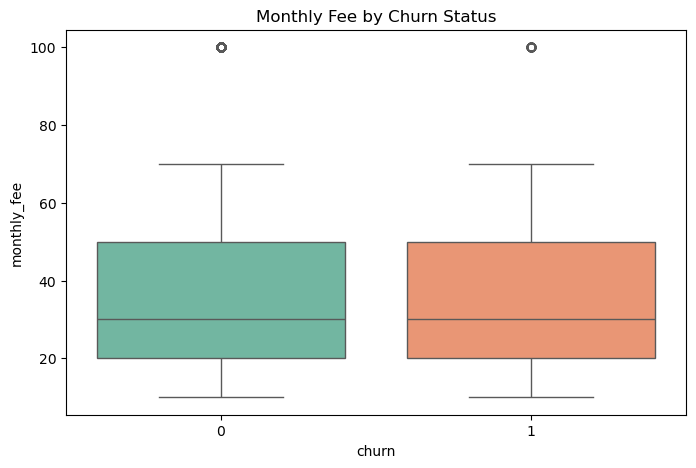

In [188]:
# 2. Numeric: Monthly Fee vs Churn
#The boxplot shows that churned and non-churned customers have similar monthly fees, meaning price alone does not drive churn
plt.figure(figsize=(8,5))
sns.boxplot(x='churn', y='monthly_fee', data=df, palette='Set2')
plt.title('Monthly Fee by Churn Status')
plt.show()

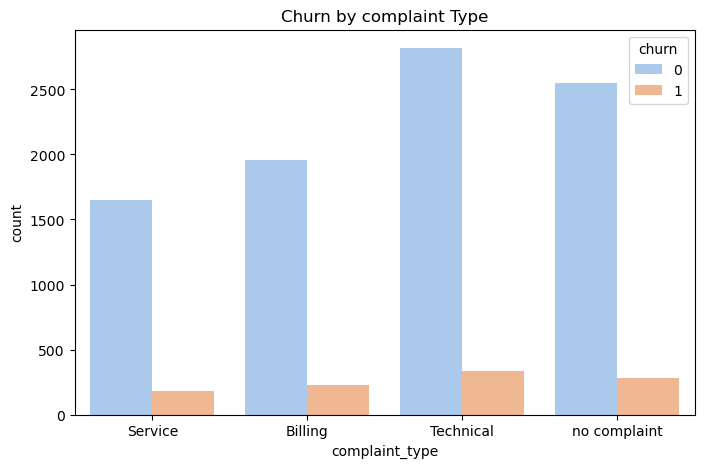

In [234]:
# 3. Categorical: Complaint Type vs Churn
# In Unchurn the highest is Technical complaint (2700) while the lowest is Service (1600)
# In Churn the same as Unchurn , that's mean either churn or unchurn they have problems with technical 
plt.figure(figsize=(8,5))
sns.countplot(x='complaint_type', hue='churn', data=df, palette='pastel')
plt.title('Churn by complaint Type')
plt.show()

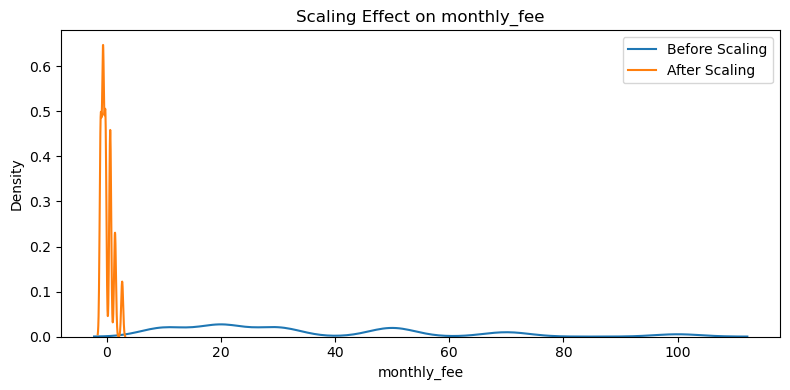

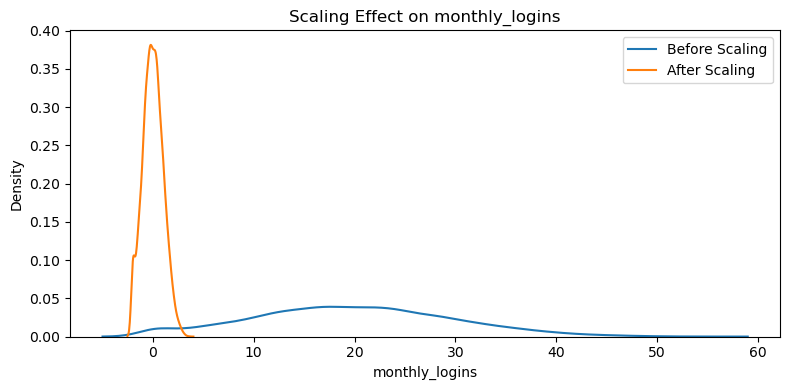

In [232]:
#It shows the effect of feature scaling using StandardScaler. While the original features have different numeric ranges, scaling centers them around zero with unit variance. 
#This ensures that distance-based models such as KNN are not dominated by high-magnitude features.
from sklearn.preprocessing import StandardScaler

numeric_cols = X_train.select_dtypes(include="number").columns
scaler = StandardScaler()

before = X_train[numeric_cols].copy()
after = pd.DataFrame(scaler.fit_transform(before), columns=numeric_cols, index=X_train.index)

# compare one or two key columns
cols_show = [c for c in ["monthly_fee", "monthly_logins"] if c in numeric_cols]
for col in cols_show:
    plt.figure(figsize=(8,4))
    sns.kdeplot(before[col], label="Before Scaling")
    sns.kdeplot(after[col], label="After Scaling")
    plt.title(f"Scaling Effect on {col}")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [192]:
# Fill 'None' complaint types with 'no complaint'
df["complaint_type"] = df["complaint_type"].fillna("no complaint")

In [17]:
df.head(20)

,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,weekly_active_days,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,7,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,5,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,Male,24,Germany,New York,SME,58,Web,Yearly,19,5,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,7,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,6,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0
5,Female,36,India,London,Individual,54,Mobile,Monthly,1,3,...,36.038391,Technical,4.0,1,0.83,0.05,-40,Neutral,1,0
6,Male,23,India,Toronto,SME,54,Mobile,Monthly,21,4,...,36.892928,Billing,4.0,0,0.75,0.46,-3,Neutral,1,0
7,Male,37,Bangladesh,Sydney,Individual,7,Referral,Yearly,17,7,...,25.024133,Technical,4.0,1,0.54,0.13,28,Satisfied,1,0
8,Male,44,India,Delhi,SME,15,Referral,Monthly,29,4,...,32.465536,Technical,2.0,0,0.85,0.13,-24,Satisfied,0,0
9,Female,70,Bangladesh,Berlin,Individual,17,Mobile,Monthly,18,5,...,42.986192,Billing,4.0,0,0.72,0.13,17,Neutral,1,0


In [ ]:
cols_to_null = ['complaint_type', 'email_open_rate', 'weekly_active_days']

# Create about 10% nulls in each selected column
for col in cols_to_null:
    df.loc[df.sample(frac=0.1).index, col] = np.nan

# Check how many nulls were added
print(df.isnull().sum())


gender                       0
age                          0
country                      0
city                         0
customer_segment             0
tenure_months                0
signup_channel               0
contract_type                0
monthly_logins               0
weekly_active_days        1000
avg_session_time             0
features_used                0
usage_growth_rate            0
last_login_days_ago          0
monthly_fee                  0
total_revenue                0
payment_method               0
payment_failures             0
discount_applied             0
price_increase_last_3m       0
support_tickets              0
avg_resolution_time          0
complaint_type            1000
csat_score                   0
escalations                  0
email_open_rate           1000
marketing_click_rate         0
nps_score                    0
survey_response              0
referral_count               0
churn                        0
dtype: int64


In [ ]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Split features and target
X = df.drop("churn", axis=1)
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
# Select numeric columns for analysis

numeric_df = X_train.select_dtypes(include=["number"])

# Compute statistics
stats = numeric_df.agg(["mean", "std", "var"])

stats


,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count
mean,45.949143,30.237714,19.716857,3.485324,15.250642,4.998143,0.020980,9.499857,35.005714,1.059844e+03,0.497429,1.212143,23.942552,3.479714,0.290857,0.502930,0.254693,18.972000,0.984000
std,16.463826,17.111597,9.787956,2.309460,6.805228,2.228771,0.150214,9.808933,23.894323,1.024840e+03,0.708767,1.103189,9.933286,0.975710,0.543022,0.232204,0.140421,38.962048,0.994068
var,271.057565,292.806750,95.804088,5.333607,46.311125,4.967420,0.022564,96.215174,570.938673,1.050298e+06,0.502351,1.217026,98.670180,0.952010,0.294873,0.053919,0.019718,1518.041222,0.988171


In [ ]:

# Compute mean from training data
email_mean = df["email_open_rate"].mean()

X_train["email_open_rate"] = X_train["email_open_rate"].fillna(email_mean)
X_test["email_open_rate"] = X_test["email_open_rate"].fillna(email_mean)

# Compute median from training data
weekly_median = X_train["weekly_active_days"].median()

X_train["weekly_active_days"] = X_train["weekly_active_days"].fillna(weekly_median)
X_test["weekly_active_days"] = X_test["weekly_active_days"].fillna(weekly_median)

# Compute mode from training data
comp_mode = X_train["complaint_type"].mode()[0]

X_train["complaint_type"] = X_train["complaint_type"].fillna(comp_mode)
X_test["complaint_type"] = X_test["complaint_type"].fillna(comp_mode)


In [ ]:
# Encode using label encoder

# Identify categorical columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    
    # Fit on training data
    X_train[col] = le.fit_transform(X_train[col])
    
    # Transform test data
    X_test[col] = le.transform(X_test[col])
    
    label_encoders[col] = le  # save encoder if needed later
    
print(X_train.dtypes)


gender                      int32
age                         int64
country                     int32
city                        int32
customer_segment            int32
tenure_months               int64
signup_channel              int32
contract_type               int32
monthly_logins              int64
weekly_active_days        float64
avg_session_time          float64
features_used               int64
usage_growth_rate         float64
last_login_days_ago         int64
monthly_fee                 int64
total_revenue               int64
payment_method              int32
payment_failures            int64
discount_applied            int32
price_increase_last_3m      int32
support_tickets             int64
avg_resolution_time       float64
complaint_type              int32
csat_score                float64
escalations                 int64
email_open_rate           float64
marketing_click_rate      float64
nps_score                   int64
survey_response             int32
referral_count

In [25]:
X_train.shape

(7000, 30)

In [26]:
#number of rows 
train_size = X_train.shape[0]
test_size = X_test.shape[0]
print("train size: " , train_size)
print("test size: " , test_size)

train size:  7000
test size:  3000


In [27]:
X_train

,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,weekly_active_days,...,support_tickets,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count
1078,0,20,4,4,2,29,2,1,30,0.0,...,1,14.694333,2,5.0,1,0.33,0.39,-1,2,2
6331,0,74,3,3,1,7,0,1,16,1.0,...,3,11.037461,2,2.0,0,0.56,0.31,26,1,0
6323,1,44,1,6,1,39,2,2,0,4.0,...,1,20.288673,2,3.0,1,0.12,0.26,97,0,0
7739,1,33,3,4,0,27,0,2,0,1.0,...,2,18.770543,1,5.0,0,0.69,0.03,10,1,0
547,0,66,5,2,0,30,2,0,34,3.0,...,0,15.459305,2,5.0,1,0.71,0.02,-31,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2250,1,36,0,6,2,48,0,2,11,0.0,...,0,19.598719,2,3.0,0,0.75,0.46,-2,1,1
9800,0,59,4,0,2,29,1,0,28,4.0,...,4,10.014003,0,5.0,0,0.42,0.13,61,1,1
5340,0,48,0,6,1,22,1,1,35,3.0,...,0,34.402062,2,2.0,0,0.47,0.17,17,0,1
4128,0,50,2,3,1,27,2,1,18,3.0,...,2,28.874238,2,5.0,1,0.47,0.24,51,0,1


In [34]:
# Check for duplicate rows in training data
X_train.duplicated().sum()

0

In [35]:
# Check for missing values
df.isnull().sum()

gender                       0
age                          0
country                      0
city                         0
customer_segment             0
tenure_months                0
signup_channel               0
contract_type                0
monthly_logins               0
weekly_active_days        1000
avg_session_time             0
features_used                0
usage_growth_rate            0
last_login_days_ago          0
monthly_fee                  0
total_revenue                0
payment_method               0
payment_failures             0
discount_applied             0
price_increase_last_3m       0
support_tickets              0
avg_resolution_time          0
complaint_type            1000
csat_score                   0
escalations                  0
email_open_rate           1000
marketing_click_rate         0
nps_score                    0
survey_response              0
referral_count               0
churn                        0
dtype: int64

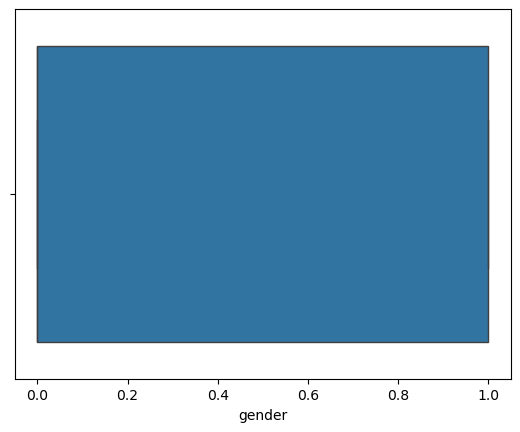

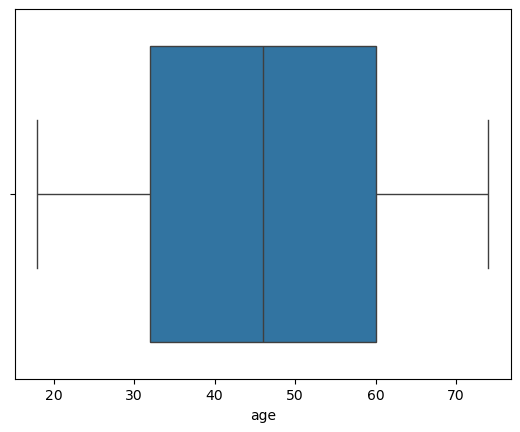

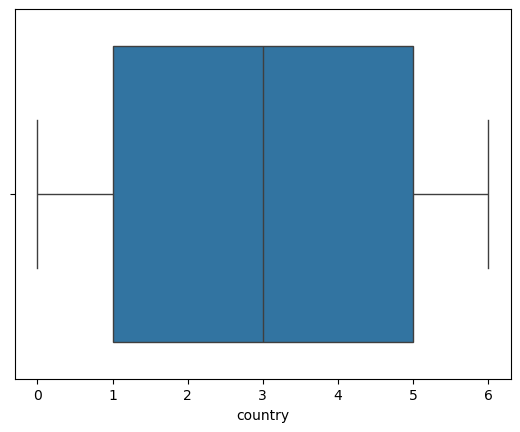

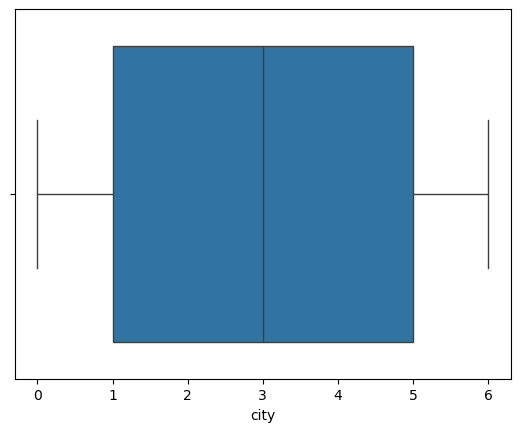

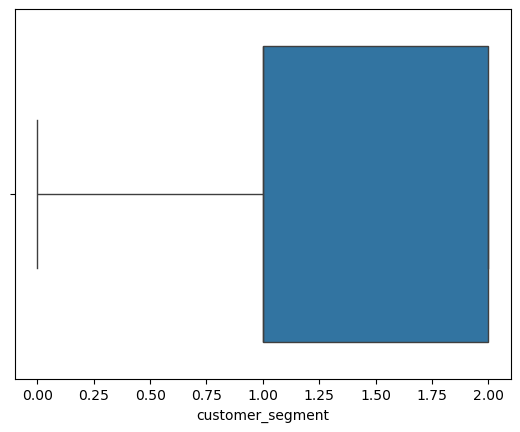

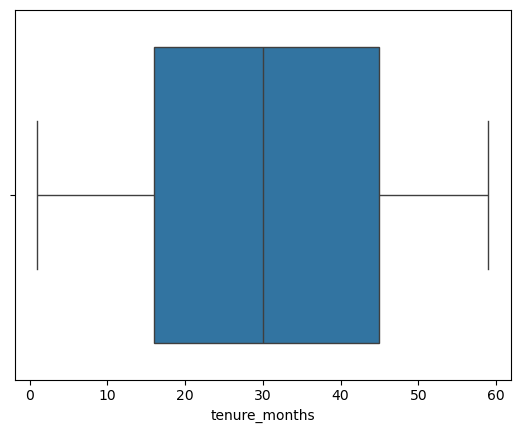

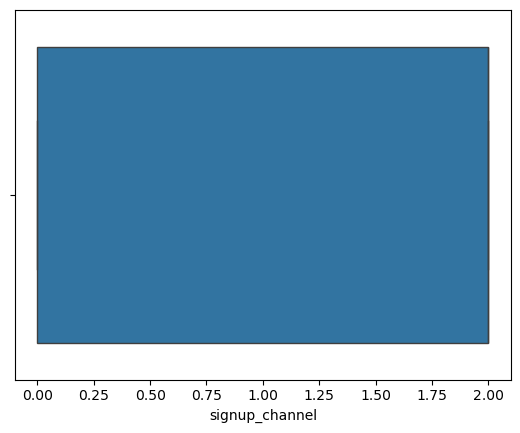

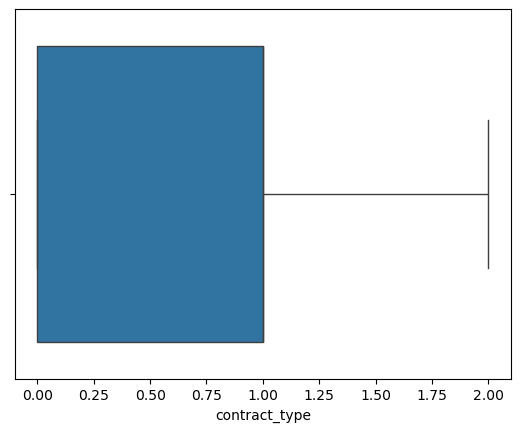

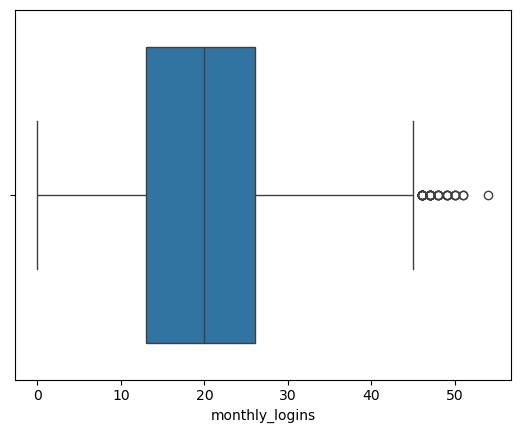

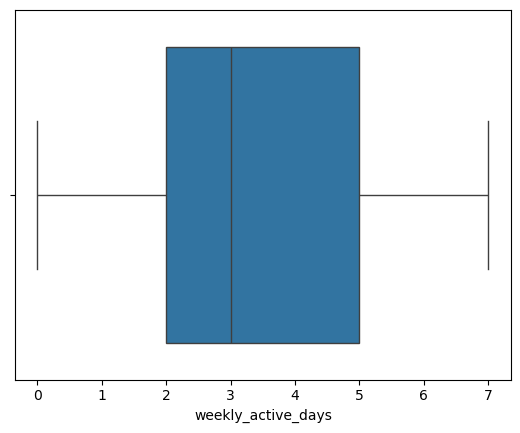

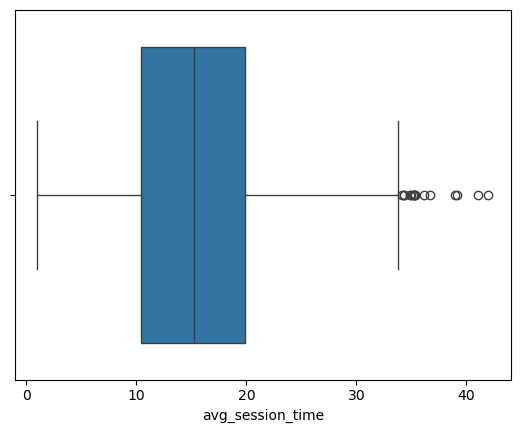

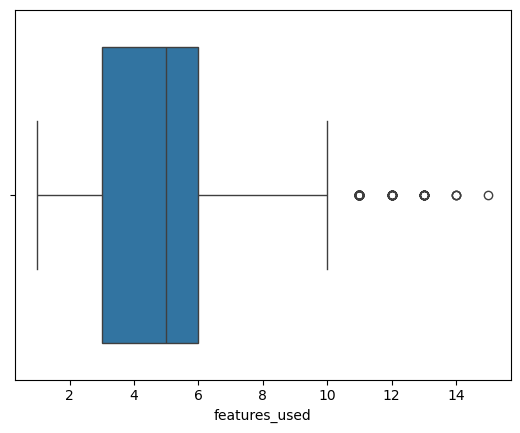

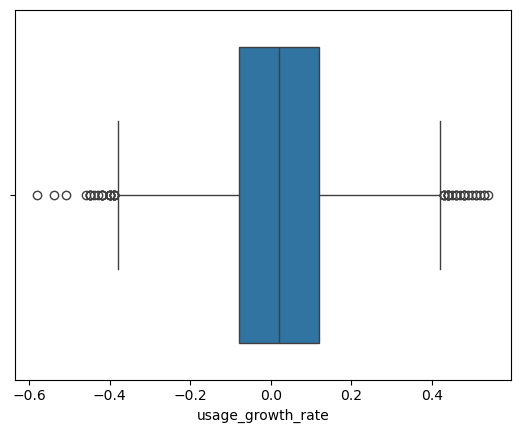

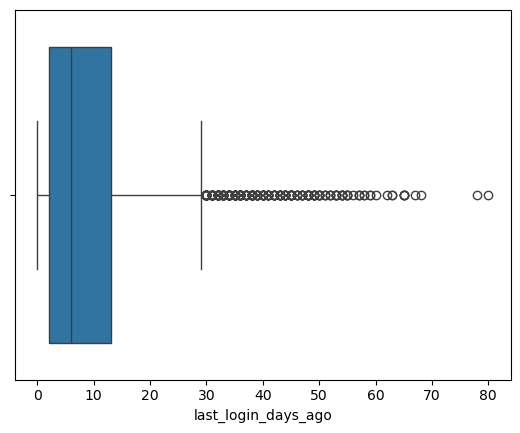

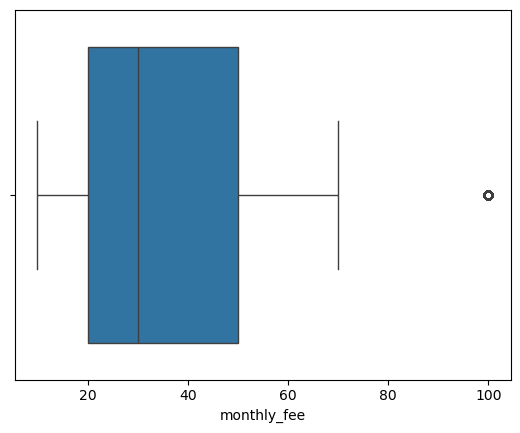

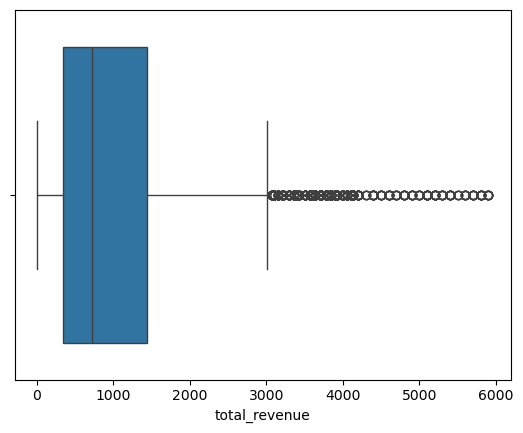

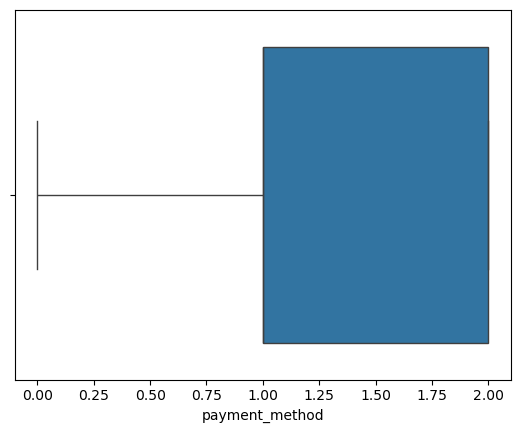

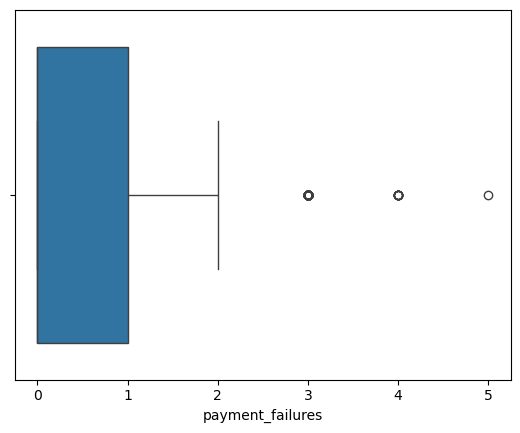

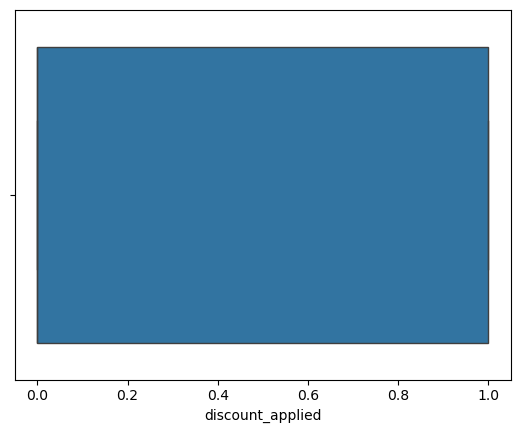

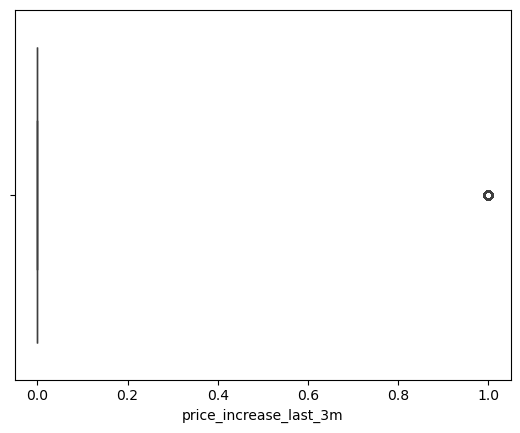

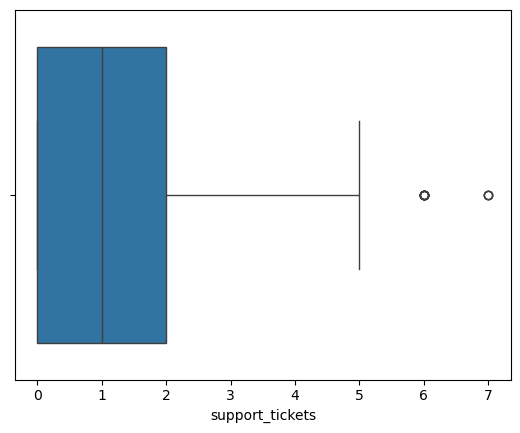

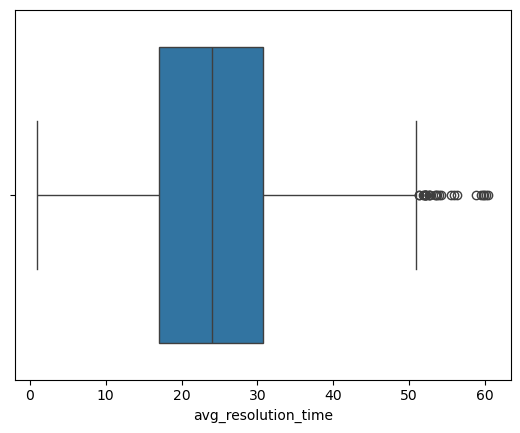

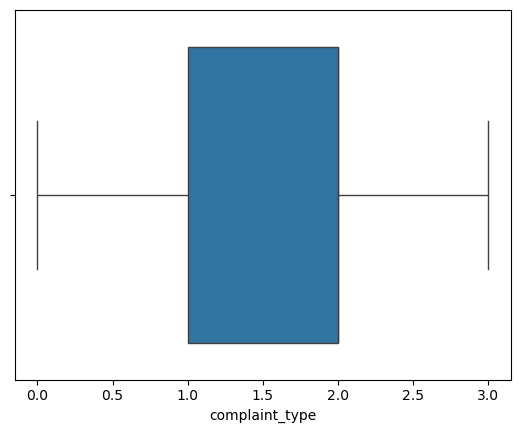

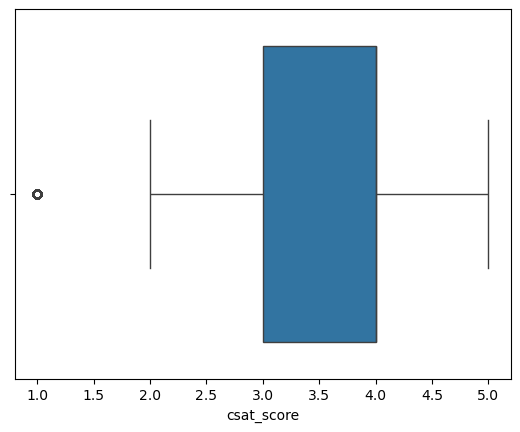

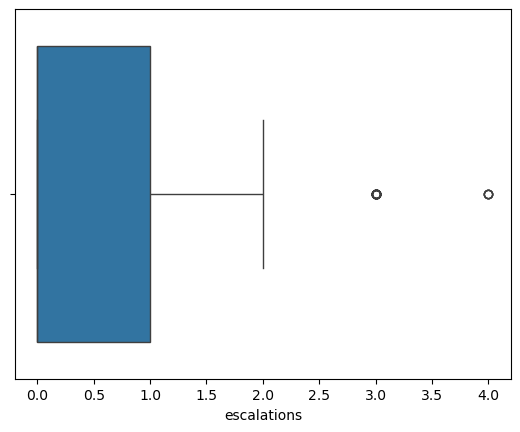

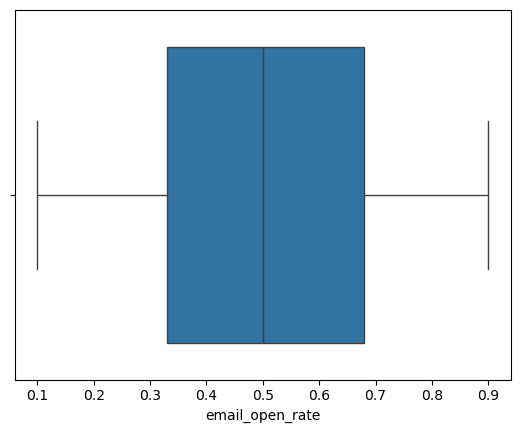

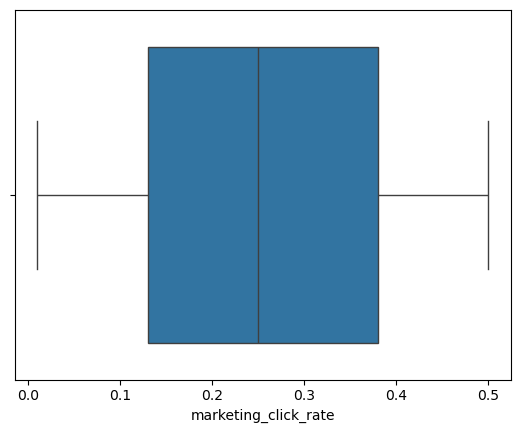

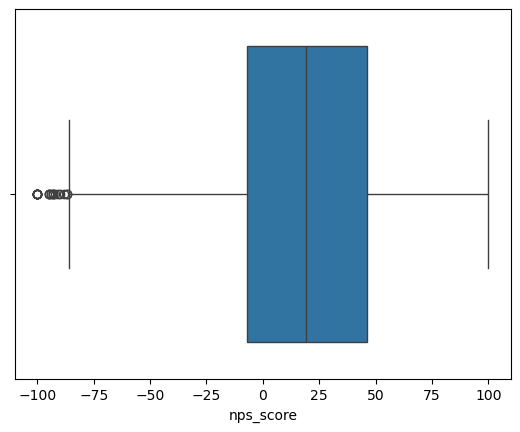

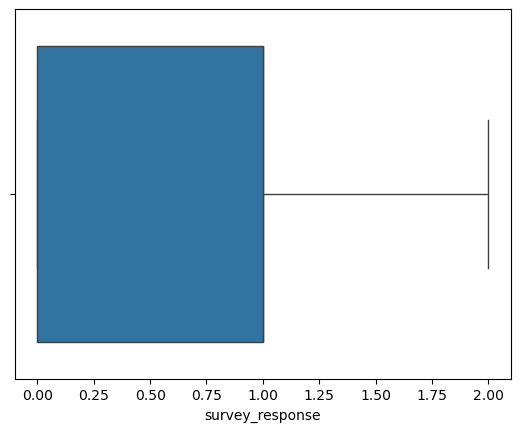

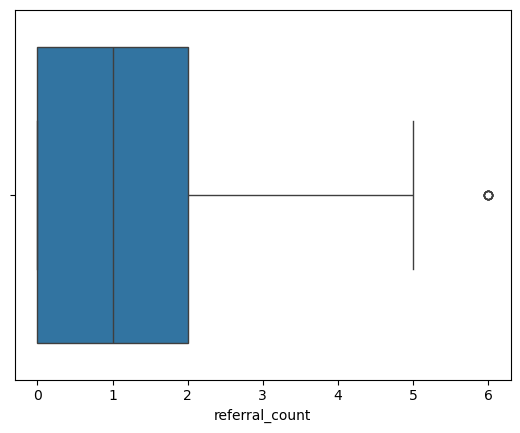

In [36]:
# Define function to detect outliers using IQR method
def outlier(i):
    q1=X_train[i].quantile(0.25)
    q3=X_train[i].quantile(0.75)
    IQR=q3-q1
    lowerbound= q1-1.5*IQR
    upperbound= q3+1.5*IQR
    return lowerbound,upperbound
    
for i in X_train.select_dtypes(include="number").columns:
    sns.boxplot(data=X_train,x=i)
    plt.show()
    


In [42]:
# Select numerical columns
numeric_cols = df.select_dtypes(include='number').columns

outliers_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_summary[col] = {
        'outlier_count': outliers.shape[0],
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    }

# Convert to DataFrame for readability
outliers_df = pd.DataFrame(outliers_summary).T

print(outliers_df)

                      outlier_count  lower_bound  upper_bound
age                             0.0   -10.000000   102.000000
tenure_months                   0.0   -27.500000    88.500000
monthly_logins                 49.0    -6.500000    45.500000
weekly_active_days              0.0    -5.000000    11.000000
avg_session_time               27.0    -3.843939    34.117618
features_used                 121.0    -1.500000    10.500000
usage_growth_rate              78.0    -0.380000     0.420000
last_login_days_ago           471.0   -14.500000    29.500000
monthly_fee                   513.0   -25.000000    95.000000
total_revenue                 513.0 -1310.000000  3090.000000
payment_failures              147.0    -1.500000     2.500000
support_tickets                18.0    -3.000000     5.000000
avg_resolution_time            38.0    -3.432619    51.273140
csat_score                    221.0     1.500000     5.500000
escalations                    43.0    -1.500000     2.500000
email_op

total_revenue IQR bounds used for capping: -1310.0 3090.0


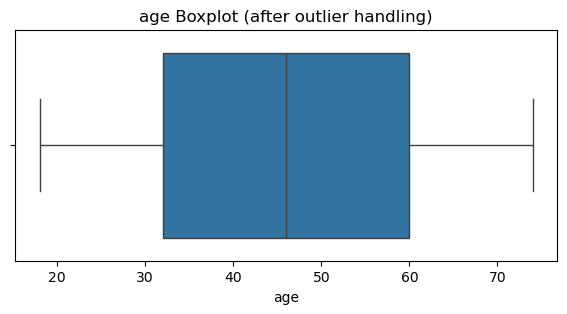

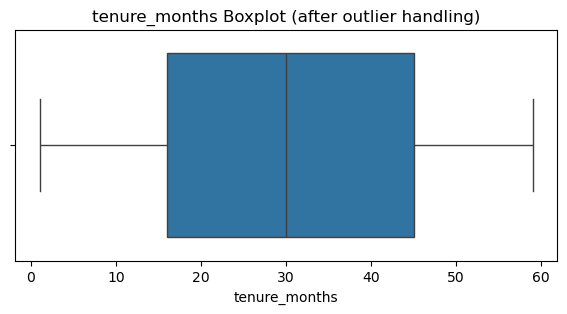

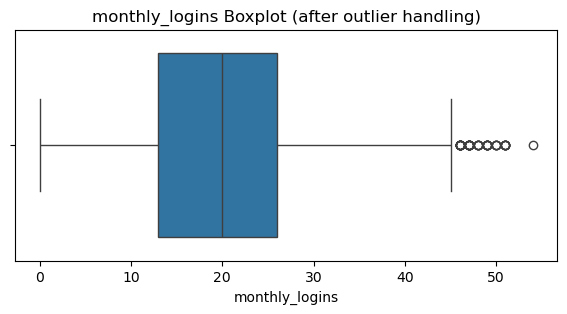

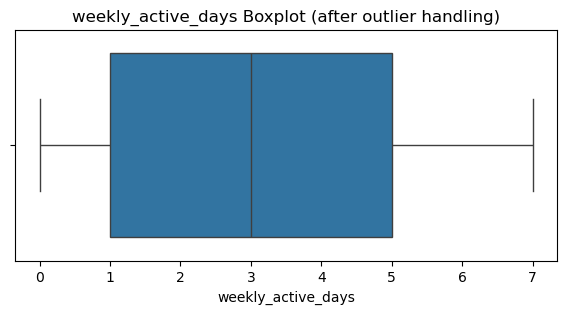

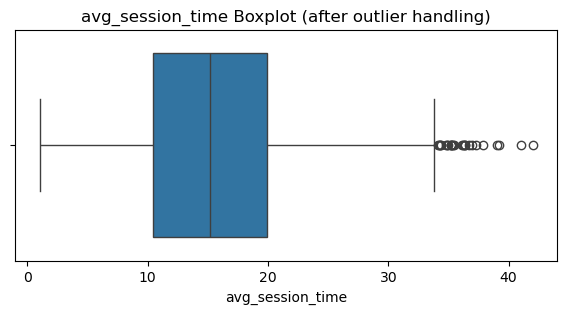

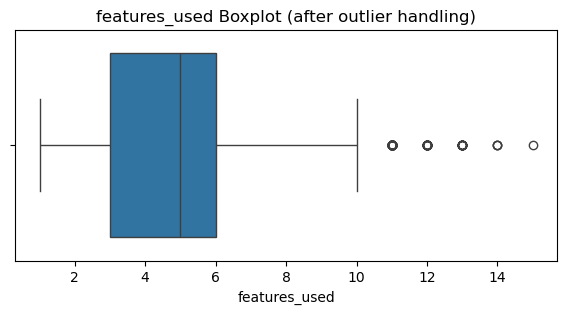

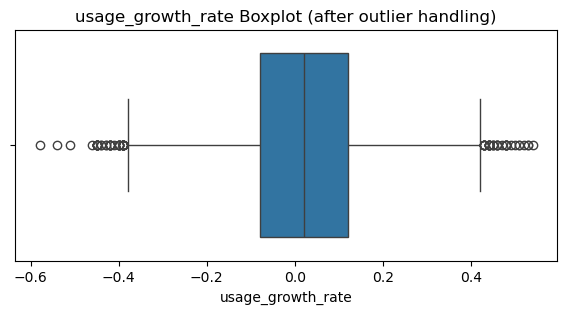

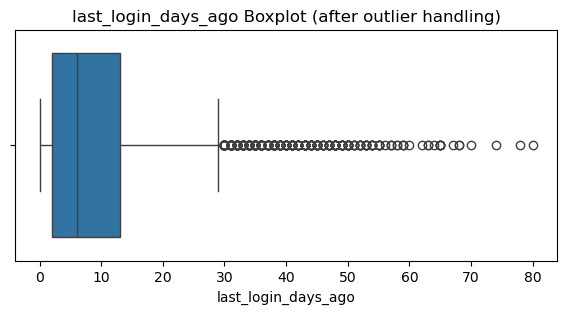

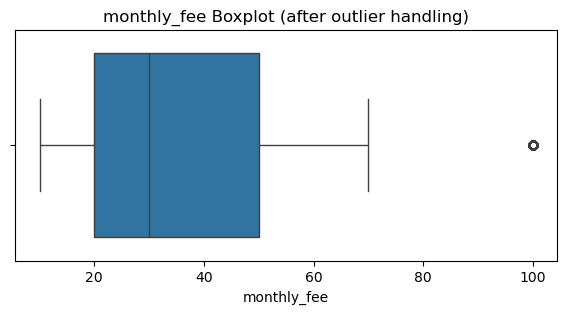

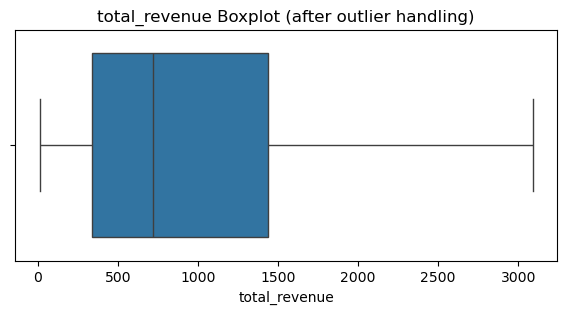

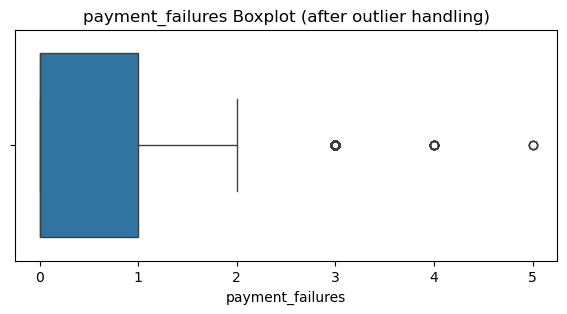

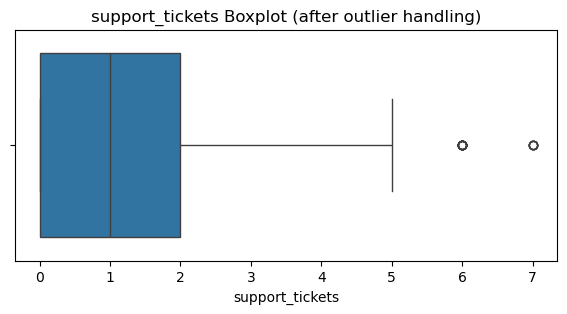

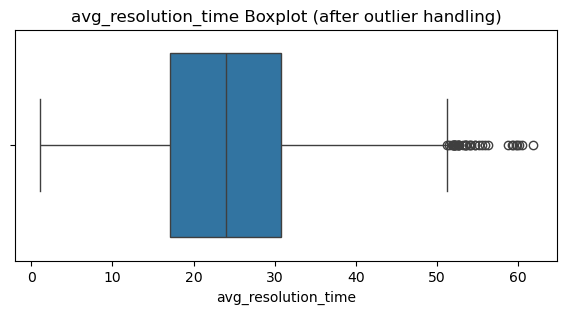

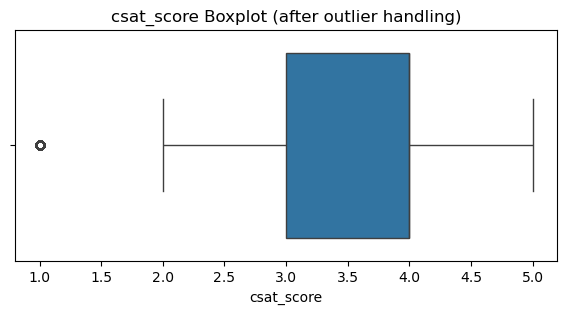

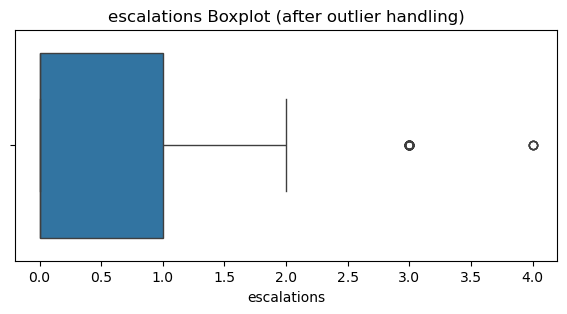

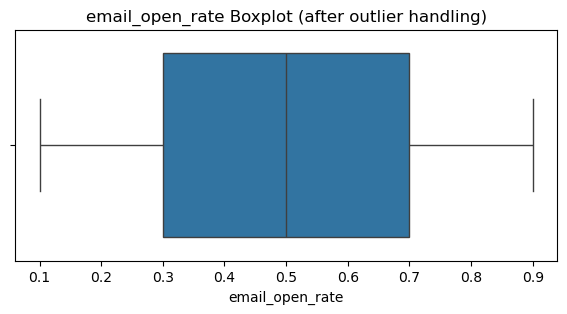

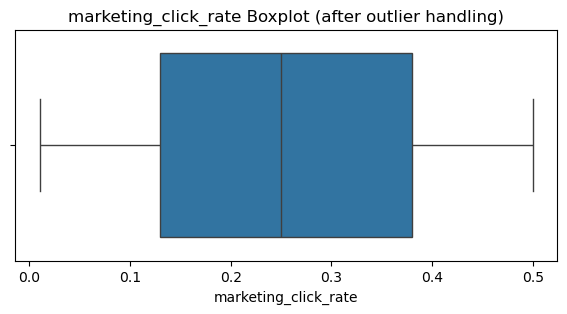

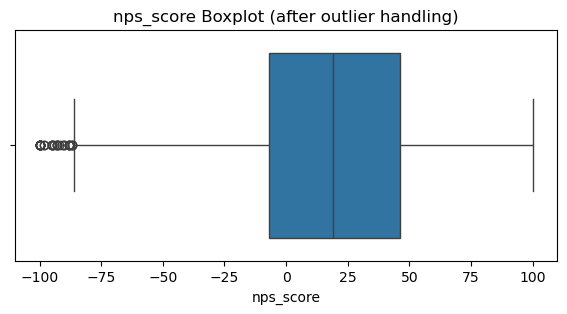

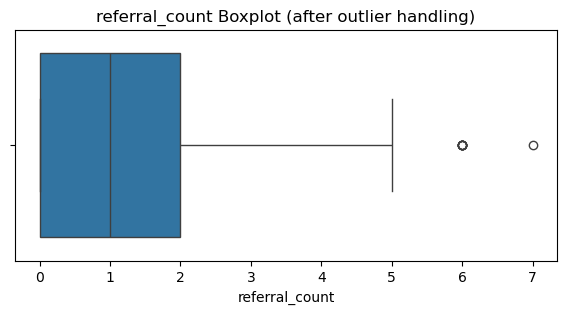

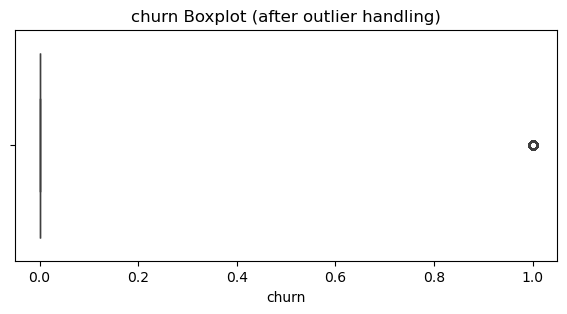

In [43]:
# Cap outliers in monthly_fee at 95th percentile
# 1) CAP monthly_fee at 95th percentile (directly on df)
monthly_fee_cap = df["monthly_fee"].quantile(0.95)
df["monthly_fee"] = df["monthly_fee"].clip(upper=monthly_fee_cap)

# 2) CAP total_revenue using IQR bounds (directly on df) (it has the largest outlier)
Q1 = df["total_revenue"].quantile(0.25)
Q3 = df["total_revenue"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["total_revenue"] = df["total_revenue"].clip(lower=lower, upper=upper)

print("total_revenue IQR bounds used for capping:", lower, upper)

# 3) Show BOXPLOTS for ALL numeric features (original df, now handled)
for col in df.select_dtypes(include="number").columns:
    plt.figure(figsize=(7, 3))
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot (after outlier handling)")
    plt.show()


In [54]:
# Select numeric columns for analysis
numeric_df = X_train.select_dtypes(include=["number"])

# Compute statistics
stats = numeric_df.agg(["mean", "std", "var"])

stats


,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,weekly_active_days,...,support_tickets,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count
mean,0.496429,45.949143,2.976857,2.997000,1.197571,30.237714,1.203571,0.705857,19.716857,3.437000,...,1.212143,23.942552,1.569000,3.479714,0.290857,0.502744,0.254693,18.972000,0.911571,0.984000
std,0.500023,16.463826,1.996004,1.970671,0.600728,17.111597,0.869455,0.779191,9.787956,2.196264,...,1.103189,9.933286,1.023280,0.975710,0.543022,0.220217,0.140421,38.962048,0.701504,0.994068
var,0.250023,271.057565,3.984034,3.883546,0.360874,292.806750,0.755952,0.607138,95.804088,4.823577,...,1.217026,98.670180,1.047103,0.952010,0.294873,0.048496,0.019718,1518.041222,0.492108,0.988171


# Clustring Using Kmeans

In [244]:
# Clustering analysis (KMeans)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1) Choose numeric features for clustering (edit this list to match your columns)
cluster_features = [
    "monthly_logins",
    "payment_failures",
    "weekly_active_days",
    "csat_score",
    "nps_score",
    "escalations",
    "email_open_rate",
    "marketing_click_rate",
    "features_used",
    "usage_growth_rate",
    "support_tickets",
    "last_login_days_ago",
    "monthly_fee"
]

# 2) Take TRAIN data only
Xc_train = X_train[cluster_features].copy()

# 3) Scale (important for K-Means)
scaler = StandardScaler()
Xc_scaled = scaler.fit_transform(Xc_train)

# 4) KMeans on scaled data
kmeans = KMeans(n_clusters=4, random_state=42, n_init="auto")
y_kmeans = kmeans.fit_predict(Xc_scaled)

# 5) PCA to 2D for visualization (like make_blobs scatter)
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(Xc_scaled)

# transform cluster centers to the same PCA space
centers_2d = pca.transform(kmeans.cluster_centers_)


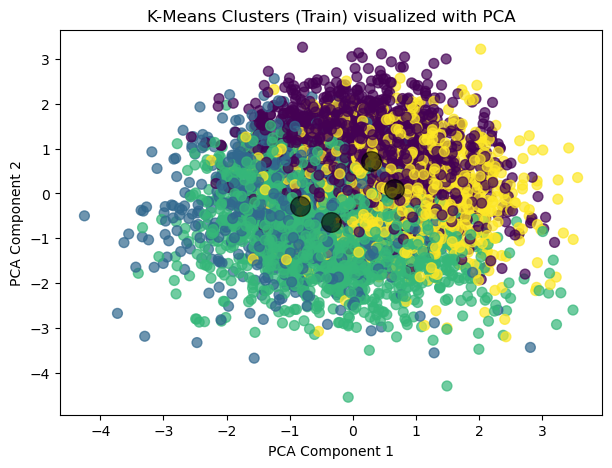

In [246]:
#The plot shows customer groups formed by K-Means,
# where each color represents a cluster of customers with similar usage behavior.

plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_kmeans, s=50, cmap="viridis", alpha=0.7)
plt.scatter(centers_2d[:, 0], centers_2d[:, 1], c="black", s=200, alpha=0.6)
plt.title("K-Means Clusters (Train) visualized with PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [ ]:

!pip install -U imbalanced-learn

# Logistic Regression Model

In [59]:
# Perform Sequential Feature Selection (SFS)
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

with mlflow.start_run(run_name="LR_SFS_Grid"):

    print("=== LR: SFS(best) + GridSearch ===")

    # ---- SFS ----
    base_lr = LogisticRegression(max_iter=2000, solver="liblinear")

    sfs_lr = SFS(
        estimator=base_lr,
        k_features="best",
        forward=True,
        floating=False,
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    )

    sfs_lr = sfs_lr.fit(X_train, y_train)
    lr_features = list(sfs_lr.k_feature_names_)

    X_train_sfs = X_train[lr_features]
    X_test_sfs  = X_test[lr_features]

    print("Selected Features:", lr_features)
    print("SFS Best CV AUC:", sfs_lr.k_score_)

    # ---- GridSearch ----
    param_grid_lr = {
        "penalty": ["l2", "l1"],
        "C": [0.01, 0.1, 1, 10],
        "solver": ["liblinear", "saga"],
        "max_iter": [500]
    }

    grid_lr = GridSearchCV(
        estimator=LogisticRegression(),
        param_grid=param_grid_lr,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1,
        error_score="raise"
    )

    grid_lr.fit(X_train_sfs, y_train)
    best_lr = grid_lr.best_estimator_

    # ---- Evaluate ----
    y_pred_lr = best_lr.predict(X_test_sfs)
    prob_lr = best_lr.predict_proba(X_test_sfs)[:, 1]

    acc_lr = accuracy_score(y_test, y_pred_lr)
    auc_lr = roc_auc_score(y_test, prob_lr)

    print("Best Params:", grid_lr.best_params_)
    print("Accuracy:", acc_lr)
    print("AUC:", auc_lr)
    print(classification_report(y_test, y_pred_lr))

    # ---- MLflow logs ----
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("sfs_cv", 5)
    mlflow.log_param("sfs_scoring", "roc_auc")
    mlflow.log_param("selected_features_count", len(lr_features))
    mlflow.log_metric("sfs_best_cv_auc", float(sfs_lr.k_score_))

    mlflow.log_params(grid_lr.best_params_)
    mlflow.log_metric("accuracy", float(acc_lr))
    mlflow.log_metric("roc_auc", float(auc_lr))

    mlflow.sklearn.log_model(best_lr, "model")

    # keep these for plotting cells
    LR_bundle = {
        "name": "LR",
        "y_pred": y_pred_lr,
        "y_prob": prob_lr,
        "best_model": best_lr,
        "X_train_sfs": X_train_sfs
    }


=== LR: SFS(best) + GridSearch ===
Selected Features: ['customer_segment', 'tenure_months', 'monthly_logins', 'last_login_days_ago', 'payment_failures', 'discount_applied', 'avg_resolution_time', 'csat_score', 'survey_response', 'referral_count']
SFS Best CV AUC: 0.7314373772607663


2025/12/20 00:02:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Best Params: {'C': 1, 'max_iter': 500, 'penalty': 'l2', 'solver': 'saga'}
Accuracy: 0.8966666666666666
AUC: 0.7241788821442954
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      2694
           1       0.17      0.00      0.01       306

    accuracy                           0.90      3000
   macro avg       0.53      0.50      0.48      3000
weighted avg       0.82      0.90      0.85      3000



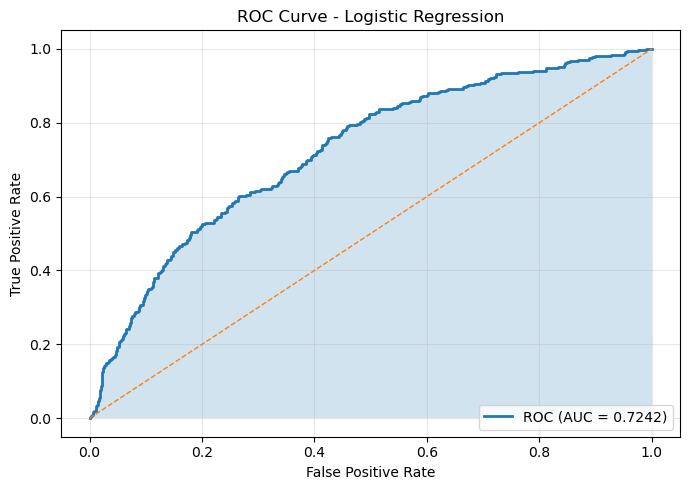

In [61]:
# Compute and plot ROC curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, LR_bundle["y_prob"])
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {roc_auc_val:.4f})')
plt.plot([0, 1], [0, 1], '--', linewidth=1)
plt.fill_between(fpr, tpr, alpha=0.2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("roc_lr.png", dpi=200)
plt.show()

mlflow.log_artifact("roc_lr.png")


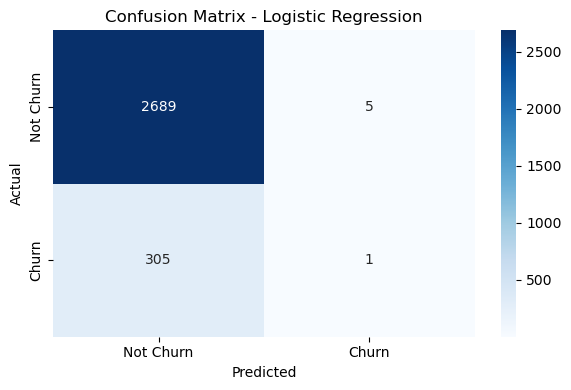

In [65]:
# Compute and plot Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, LR_bundle["y_pred"])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Not Churn', 'Churn'],
            yticklabels=['Not Churn', 'Churn'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.savefig("cm_lr.png", dpi=200)
plt.show()

mlflow.log_artifact("cm_lr.png")


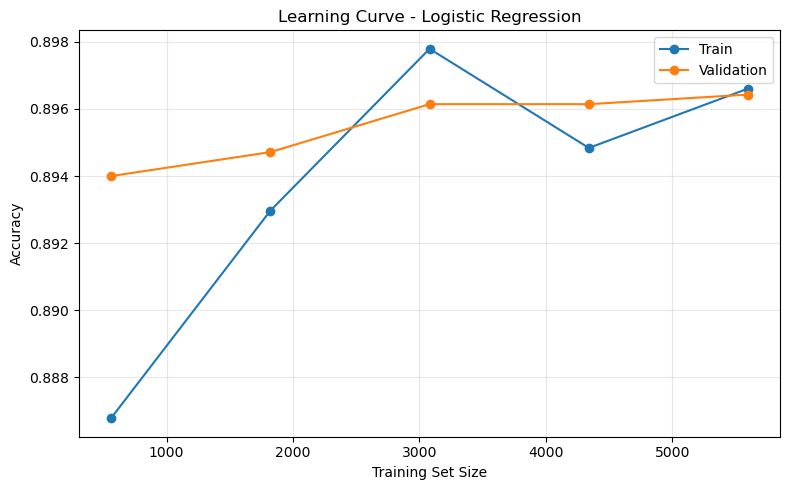

In [248]:
"""
The learning curve shows stable and similar training and validation accuracies,
indicating that the logistic regression model neither overfits nor underfits the data. 
This reflects low variance and relatively low bias, suggesting good generalization performance
"""
from sklearn.model_selection import learning_curve
train_sizes, train_scores, val_scores = learning_curve(
    estimator=LR_bundle["best_model"],
    X=LR_bundle["X_train_sfs"],
    y=y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="Validation")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Logistic Regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("lc_lr.png", dpi=200)
plt.show()

mlflow.log_artifact("lc_lr.png")


In [71]:
# End the current MLflow run
mlflow.end_run()

# KNN Model

In [75]:
# Scale numeric features using StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

In [77]:
# Perform Sequential Feature Selection (SFS)
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

with mlflow.start_run(run_name="KNN_SFS_Grid"):

    print("=== KNN: SFS(best) + GridSearch (Scaled) ===")

    # ---- SFS (USE SCALED DATA) ----
    base_knn = KNeighborsClassifier()

    sfs_knn = SFS(
        estimator=base_knn,
        k_features="best",
        forward=True,
        floating=False,
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    )

    sfs_knn = sfs_knn.fit(X_train_scaled, y_train)
    knn_features = list(sfs_knn.k_feature_names_)

    X_train_sfs = X_train_scaled[knn_features]
    X_test_sfs  = X_test_scaled[knn_features]

    print("Selected Features:", knn_features)
    print("SFS Best CV AUC:", sfs_knn.k_score_)

    # ---- GridSearch ----
    param_grid_knn = {
        "n_neighbors": [3, 5, 7, 9, 11, 15],
        "weights": ["uniform", "distance"],
        "p": [1, 2]   # Manhattan=1, Euclidean=2
    }

    grid_knn = GridSearchCV(
        estimator=KNeighborsClassifier(),
        param_grid=param_grid_knn,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1,
        error_score="raise"
    )

    grid_knn.fit(X_train_sfs, y_train)
    best_knn = grid_knn.best_estimator_

    # ---- Evaluate ----
    y_pred_knn = best_knn.predict(X_test_sfs)
    prob_knn = best_knn.predict_proba(X_test_sfs)[:, 1]

    acc_knn = accuracy_score(y_test, y_pred_knn)
    auc_knn = roc_auc_score(y_test, prob_knn)

    print("Best Params:", grid_knn.best_params_)
    print("Accuracy:", acc_knn)
    print("AUC:", auc_knn)
    print(classification_report(y_test, y_pred_knn))

    # ---- MLflow logs ----
    mlflow.log_param("model", "KNN")
    mlflow.log_param("scaling", "StandardScaler")
    mlflow.log_param("sfs_cv", 5)
    mlflow.log_param("sfs_scoring", "roc_auc")
    mlflow.log_param("selected_features_count", len(knn_features))
    mlflow.log_metric("sfs_best_cv_auc", float(sfs_knn.k_score_))

    mlflow.log_params(grid_knn.best_params_)
    mlflow.log_metric("accuracy", float(acc_knn))
    mlflow.log_metric("roc_auc", float(auc_knn))

    mlflow.sklearn.log_model(best_knn, "model")

    # ---- Bundle for plots ----
    KNN_bundle = {
        "name": "KNN",
        "y_pred": y_pred_knn,
        "y_prob": prob_knn,
        "best_model": best_knn,
        "X_train_sfs": X_train_sfs
    }


=== KNN: SFS(best) + GridSearch (Scaled) ===
Selected Features: ['tenure_months', 'monthly_logins', 'payment_failures', 'csat_score']
SFS Best CV AUC: 0.6989429822365383


2025/12/20 00:21:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Best Params: {'n_neighbors': 15, 'p': 1, 'weights': 'uniform'}
Accuracy: 0.8976666666666666
AUC: 0.7592841269148095
              precision    recall  f1-score   support

           0       0.90      0.99      0.95      2694
           1       0.48      0.05      0.09       306

    accuracy                           0.90      3000
   macro avg       0.69      0.52      0.52      3000
weighted avg       0.86      0.90      0.86      3000



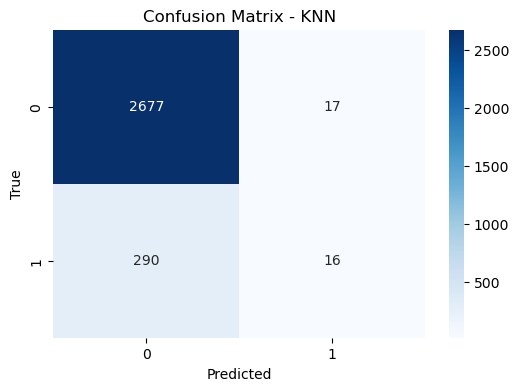

In [79]:
# Compute and plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


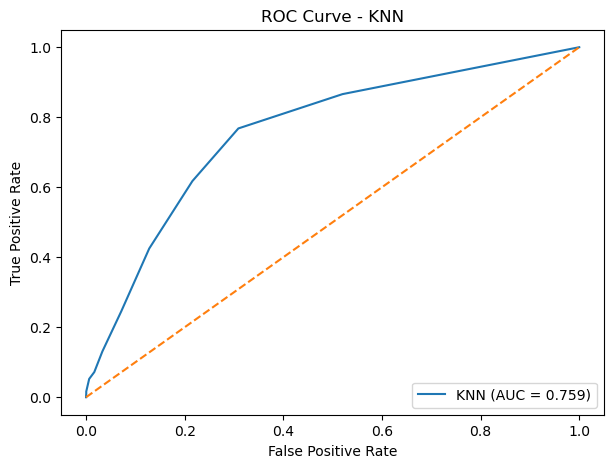

In [81]:
# Compute and plot ROC curve
fpr, tpr, _ = roc_curve(y_test, prob_knn)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"KNN (AUC = {roc_auc_val:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend(loc="lower right")
plt.show()


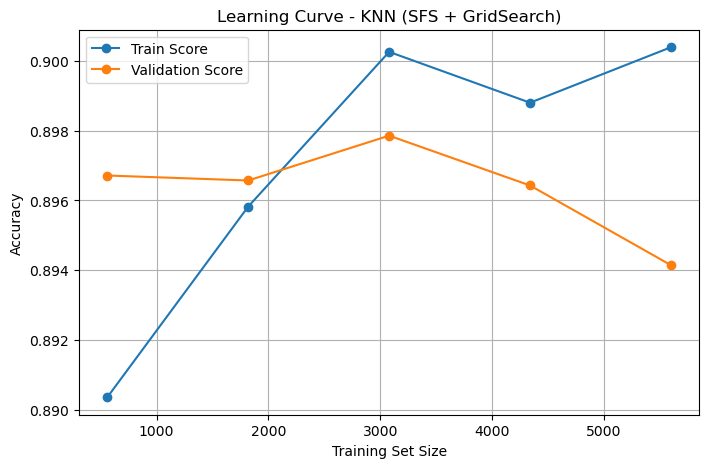

In [252]:
"""
The learning curve of KNN shows higher training accuracy compared to validation accuracy,
indicating mild overfitting. This reflects low bias but relatively higher variance,
which is typical for distance-based models such as KNN.

"""
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_knn,
    X=KNN_bundle["X_train_sfs"],
    y=y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train Score")
plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="Validation Score")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - KNN (SFS + GridSearch)")
plt.legend()
plt.grid(True)
plt.show()


In [87]:
# End the current MLflow run
mlflow.end_run()

# Random Forest Model

In [89]:
# Perform Sequential Feature Selection (SFS)
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

with mlflow.start_run(run_name="RF_SFS_Grid"):

    print("=== RF: SFS(best) + GridSearch ===")

    # ---- SFS ----
    base_rf = RandomForestClassifier(random_state=42)

    sfs_rf = SFS(
        estimator=base_rf,
        k_features="best",
        forward=True,
        floating=False,
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    )

    sfs_rf = sfs_rf.fit(X_train, y_train)
    rf_features = list(sfs_rf.k_feature_names_)

    X_train_sfs = X_train[rf_features]
    X_test_sfs  = X_test[rf_features]

    print("Selected Features:", rf_features)
    print("SFS Best CV AUC:", sfs_rf.k_score_)

    # ---- GridSearch ----
    param_grid_rf = {
        "n_estimators": [200, 400],
        "max_depth": [None, 5, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"]
    }

    grid_rf = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid=param_grid_rf,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1,
        error_score="raise"
    )

    grid_rf.fit(X_train_sfs, y_train)
    best_rf = grid_rf.best_estimator_

    # ---- Evaluate ----
    y_pred_rf = best_rf.predict(X_test_sfs)
    prob_rf = best_rf.predict_proba(X_test_sfs)[:, 1]

    acc_rf = accuracy_score(y_test, y_pred_rf)
    auc_rf = roc_auc_score(y_test, prob_rf)

    print("Best Params:", grid_rf.best_params_)
    print("Accuracy:", acc_rf)
    print("AUC:", auc_rf)
    print(classification_report(y_test, y_pred_rf))

    # ---- MLflow logs ----
    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("sfs_cv", 5)
    mlflow.log_param("sfs_scoring", "roc_auc")
    mlflow.log_param("selected_features_count", len(rf_features))
    mlflow.log_metric("sfs_best_cv_auc", float(sfs_rf.k_score_))

    mlflow.log_params(grid_rf.best_params_)
    mlflow.log_metric("accuracy", float(acc_rf))
    mlflow.log_metric("roc_auc", float(auc_rf))

    mlflow.sklearn.log_model(best_rf, "model")

    RF_bundle = {
        "name": "RF",
        "y_pred": y_pred_rf,
        "y_prob": prob_rf,
        "best_model": best_rf,
        "X_train_sfs": X_train_sfs
    }


=== RF: SFS(best) + GridSearch ===
Selected Features: ['gender', 'city', 'customer_segment', 'tenure_months', 'monthly_logins', 'avg_session_time', 'last_login_days_ago', 'payment_failures', 'support_tickets', 'csat_score', 'email_open_rate', 'survey_response']
SFS Best CV AUC: 0.8076333372276094


C:\Users\MSI\anaconda3\envs\ml_phase2\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\MSI\anaconda3\envs\ml_phase2\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\MSI\anaconda3\envs\ml_phase2\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

Best Params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy: 0.898
AUC: 0.8067928730512249
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      2694
           1       0.00      0.00      0.00       306

    accuracy                           0.90      3000
   macro avg       0.45      0.50      0.47      3000
weighted avg       0.81      0.90      0.85      3000



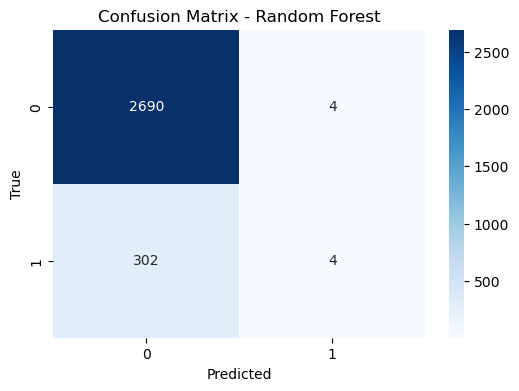

In [90]:
# Compute and plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


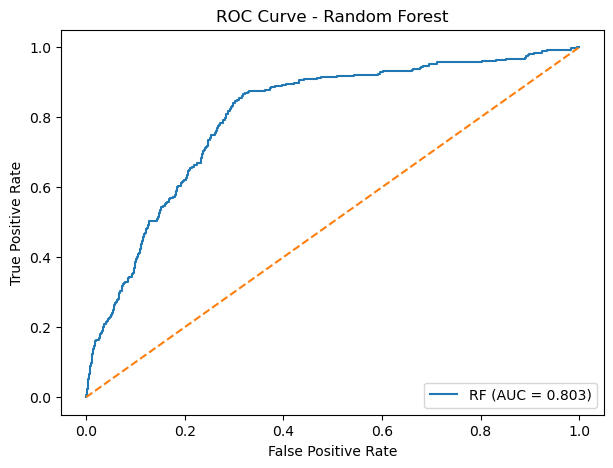

In [91]:
# Compute and plot ROC curve
fpr, tpr, _ = roc_curve(y_test, prob_rf)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"RF (AUC = {roc_auc_val:.3f})")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.show()


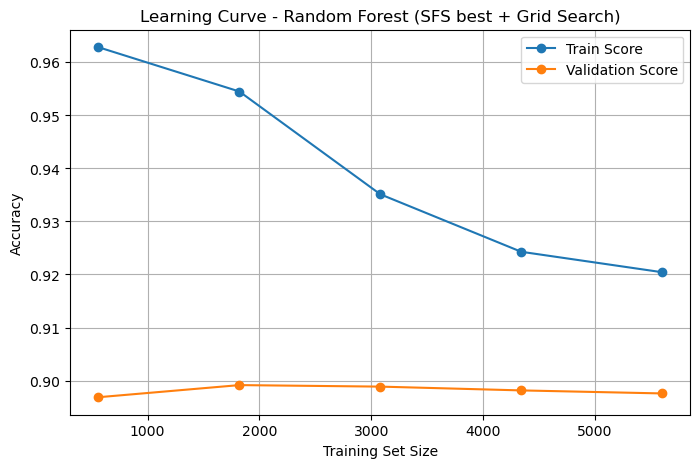

In [92]:
"""
he learning curve of Random Forest shows a large gap between training and validation accuracy,
indicating overfitting. This suggests low bias but high variance, 
meaning the model fits the training data well but generalizes poorly to unseen data.
"""
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_rf,
    X=X_train_sfs_rf,
    y=y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train Score")
plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="Validation Score")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Random Forest (SFS best + Grid Search)")
plt.legend()
plt.grid(True)
plt.show()


In [107]:
# End the current MLflow run
mlflow.end_run()

# Comparison Table between the indv models

In [257]:
"""
Although Random Forest achieved the highest accuracy, it failed to detect any churn cases, 
making it unsuitable for this imbalanced classification task. Logistic Regression showed similarly poor recall for the churn class.
KNN achieved the best balance between recall, F1-score, and ROC-AUC, correctly identifying more churners. 
Therefore, KNN was selected as the best individual model.
"""
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score,
    confusion_matrix
)

def evaluate_binary(y_true, y_pred, y_prob=None):
    """Return a dict of useful binary-classification metrics."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    out = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Class 1)": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Recall (Class 1)": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "F1 (Class 1)": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp
    }

    if y_prob is not None:
        out["ROC-AUC"] = roc_auc_score(y_true, y_prob)
    else:
        out["ROC-AUC"] = np.nan

    return out


results = []

# -------------------------
# 1) Logistic Regression
# -------------------------
Xte_lr = X_test[lr_features]
y_pred_lr = best_lr.predict(Xte_lr)

# predict_proba available for LR
y_prob_lr = best_lr.predict_proba(Xte_lr)[:, 1]

lr_row = evaluate_binary(y_test, y_pred_lr, y_prob_lr)
lr_row["Model"] = "Logistic Regression"
results.append(lr_row)


# -------------------------
# 2) KNN  (usually scaled)
# -------------------------
# If you scaled earlier, use X_test_scaled. If not, use X_test.
# Most churn projects require scaling for KNN.
Xte_knn = X_test_scaled[knn_features]  # <-- change to X_test[knn_features] if you didn't scale
y_pred_knn = best_knn.predict(Xte_knn)
y_prob_knn = best_knn.predict_proba(Xte_knn)[:, 1]

knn_row = evaluate_binary(y_test, y_pred_knn, y_prob_knn)
knn_row["Model"] = "KNN"
results.append(knn_row)


# -------------------------
# 3) Random Forest
# -------------------------
Xte_rf = X_test[rf_features]
y_pred_rf = best_rf.predict(Xte_rf)

# predict_proba available for RF
y_prob_rf = best_rf.predict_proba(Xte_rf)[:, 1]

rf_row = evaluate_binary(y_test, y_pred_rf, y_prob_rf)
rf_row["Model"] = "Random Forest"
results.append(rf_row)


# -------------------------
# Build table
# -------------------------
df_results = pd.DataFrame(results)

# reorder columns nicely
cols_order = [
    "Model",
    "Accuracy", "ROC-AUC",
    "Precision (Class 1)", "Recall (Class 1)", "F1 (Class 1)",
    "TN", "FP", "FN", "TP"
]
df_results = df_results[cols_order]

df_results = df_results.sort_values(by="ROC-AUC", ascending=False)

# show
df_results


,Model,Accuracy,ROC-AUC,Precision (Class 1),Recall (Class 1),F1 (Class 1),TN,FP,FN,TP
2,Random Forest,0.898000,0.806793,0.000000,0.000000,0.000000,2694,0,306,0
1,KNN,0.897667,0.759284,0.484848,0.052288,0.094395,2677,17,290,16
0,Logistic Regression,0.896667,0.724179,0.166667,0.003268,0.006410,2689,5,305,1


# Ensemble Coding

# 1. Hard Voting

In [109]:
# Implement Hard Voting Ensemble
# LR/KNN/RF have DIFFERENT SFS feature lists,
# so we wrap each estimator with a column selector.

from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import accuracy_score, classification_report

def select_cols(cols):
    return FunctionTransformer(lambda df: df[cols], validate=False)

lr_hard = Pipeline([("select", select_cols(lr_features)), ("clf", best_lr)])
knn_hard = Pipeline([("select", select_cols(knn_features)), ("clf", best_knn)])
rf_hard = Pipeline([("select", select_cols(rf_features)), ("clf", best_rf)])

with mlflow.start_run(run_name="Ensemble_HardVoting_LR_KNN_RF"):

    hard_vote = VotingClassifier(
        estimators=[("lr", lr_hard), ("knn", knn_hard), ("rf", rf_hard)],
        voting="hard",
        weights=[1, 1, 1]
    )

    # Train & test on SCALED full data (RF is fine with scaled; LR/KNN need it)
    hard_vote.fit(X_train_scaled, y_train)
    y_pred = hard_vote.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)

    print("=== Hard Voting (LR + KNN + RF) ===")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

    mlflow.log_param("ensemble", "VotingHard")
    mlflow.log_param("weights", "1,1,1")
    mlflow.log_metric("accuracy", float(acc))
    mlflow.sklearn.log_model(hard_vote, "model")


2025/12/20 01:20:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


=== Hard Voting (LR + KNN + RF) ===
Accuracy: 0.8983333333333333
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      2694
           1       1.00      0.00      0.01       306

    accuracy                           0.90      3000
   macro avg       0.95      0.50      0.48      3000
weighted avg       0.91      0.90      0.85      3000



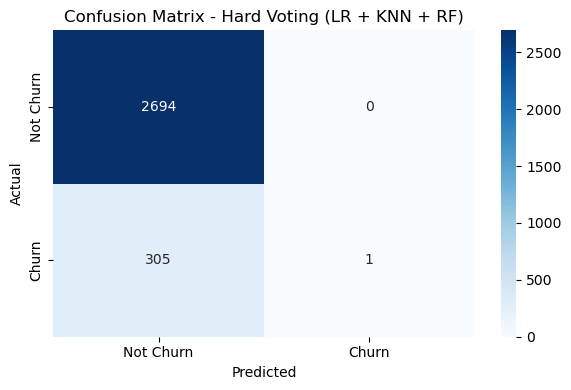

In [111]:
# Compute and plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Not Churn', 'Churn'],
                yticklabels=['Not Churn', 'Churn'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - Hard Voting (LR + KNN + RF)")
    plt.tight_layout()
    plt.savefig("cm_hard_voting.png", dpi=200)
    plt.show()

    mlflow.log_artifact("cm_hard_voting.png")

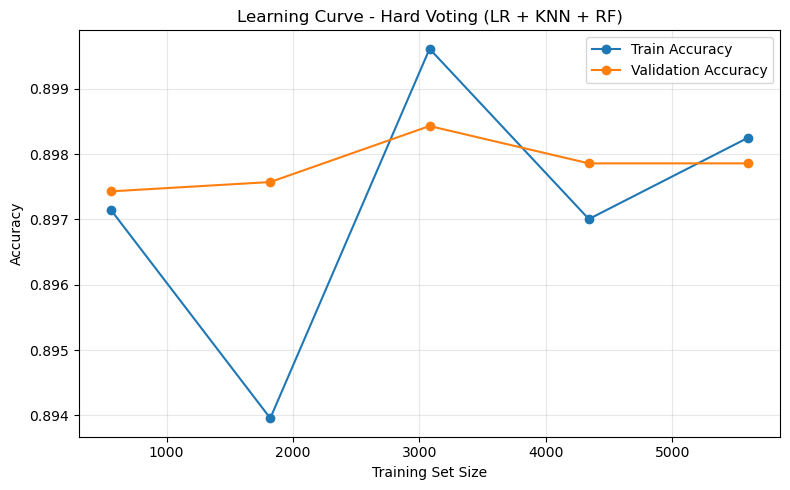

In [113]:
"""
The learning curve of the hard voting ensemble shows closely aligned training and validation accuracies, 
indicating good generalization with low bias and low variance.
The ensemble effectively balances the strengths of its base models without overfitting.
"""
train_sizes, train_scores, val_scores = learning_curve(
    estimator=hard_vote,
    X=X_train_scaled,
    y=y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train Accuracy")
plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="Validation Accuracy")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Hard Voting (LR + KNN + RF)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [115]:
# End the current MLflow run
mlflow.end_run()

# 2. Bagging Using KNN

In [216]:
# Implement Bagging with KNN
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

with mlflow.start_run(run_name="Ensemble_Bagging_KNN"):

    bag_knn = BaggingClassifier(
        estimator=best_knn,      #tuned KNN
        n_estimators=30,
        bootstrap=True,
        n_jobs=-1,
        random_state=42
    )

    # KNN must be scaled + use its SFS features
    Xtr = X_train_scaled[knn_features]
    Xte = X_test_scaled[knn_features]

    bag_knn.fit(Xtr, y_train)

    y_pred = bag_knn.predict(Xte)
    y_prob = bag_knn.predict_proba(Xte)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    aucv = roc_auc_score(y_test, y_prob)

    print("=== Bagging (KNN) ===")
    print("Accuracy:", acc)
    print("AUC:", aucv)
    print(classification_report(y_test, y_pred))

    mlflow.log_param("ensemble", "Bagging")
    mlflow.log_param("base_model", "KNN")
    mlflow.log_param("n_estimators", 30)
    mlflow.log_metric("accuracy", float(acc))
    mlflow.log_metric("roc_auc", float(aucv))
    mlflow.sklearn.log_model(bag_knn, "model")


2025/12/20 05:36:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


=== Bagging (KNN) ===
Accuracy: 0.8943333333333333
AUC: 0.7666522312958839
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      2694
           1       0.35      0.04      0.08       306

    accuracy                           0.89      3000
   macro avg       0.63      0.52      0.51      3000
weighted avg       0.85      0.89      0.86      3000



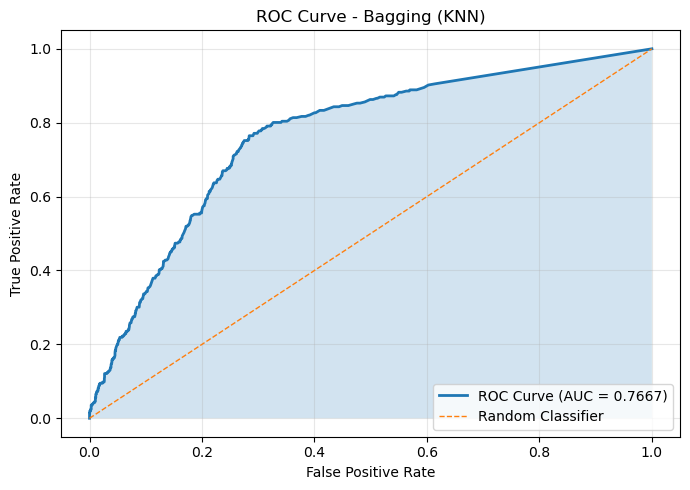

In [99]:
# Compute and plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)

    plt.figure(figsize=(7,5))
    plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {roc_auc_val:.4f})')
    plt.plot([0, 1], [0, 1], '--', linewidth=1, label='Random Classifier')
    plt.fill_between(fpr, tpr, alpha=0.2)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Bagging (KNN)')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("roc_bagging_knn.png", dpi=200)
    plt.show()

    mlflow.log_artifact("roc_bagging_knn.png")



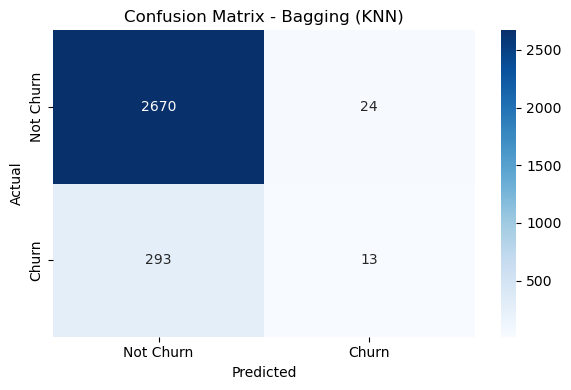

In [101]:
# Compute and plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Not Churn', 'Churn'],
                yticklabels=['Not Churn', 'Churn'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - Bagging (KNN)")
    plt.tight_layout()
    plt.savefig("cm_bagging_knn.png", dpi=200)
    plt.show()

    mlflow.log_artifact("cm_bagging_knn.png")

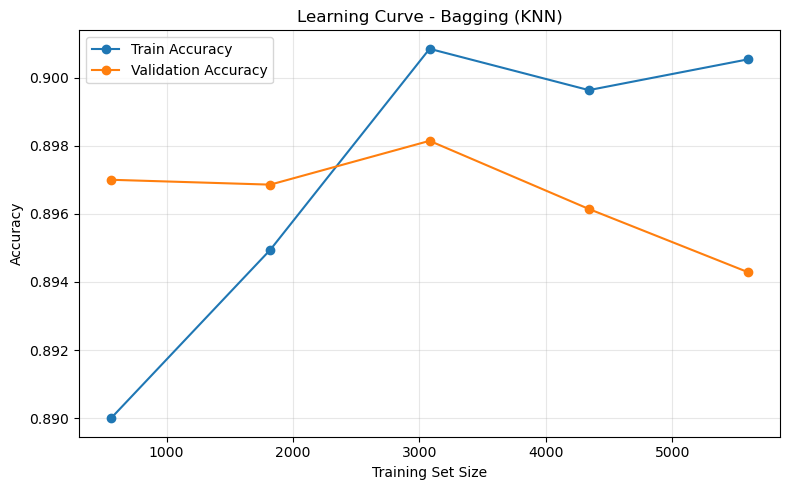

In [103]:
"""
The learning curve of bagged KNN shows slightly higher training accuracy than validation accuracy,
indicating mild overfitting. This reflects low bias and moderate variance,
where bagging reduces but does not fully remove KNN’s sensitivity to data variability
"""
train_sizes, train_scores, val_scores = learning_curve(
    estimator=bag_knn,
    X=X_train_scaled[knn_features],
    y=y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train Accuracy")
plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="Validation Accuracy")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Bagging (KNN)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [119]:
# End the current MLflow run
mlflow.end_run()

# 3. Stacking 

In [123]:
# Compute and plot ROC curve
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
import mlflow.sklearn

def select_cols(cols):
    return FunctionTransformer(lambda df: df[cols], validate=False)

lr_stack  = Pipeline([("select", select_cols(lr_features)),  ("clf", best_lr)])
knn_stack = Pipeline([("select", select_cols(knn_features)), ("clf", best_knn)])
rf_stack  = Pipeline([("select", select_cols(rf_features)),  ("clf", best_rf)])

with mlflow.start_run(run_name="Ensemble_Stacking_LR_KNN_RF"):

    stack = StackingClassifier(
        estimators=[("lr", lr_stack), ("knn", knn_stack), ("rf", rf_stack)],
        final_estimator=LogisticRegression(max_iter=2000),
        stack_method="predict_proba",
        passthrough=False,
        n_jobs=-1
    )

    stack.fit(X_train_scaled, y_train)

    y_pred = stack.predict(X_test_scaled)
    y_prob = stack.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    aucv = roc_auc_score(y_test, y_prob)

    print("=== Stacking (LR + KNN + RF) ===")
    print("Accuracy:", acc)
    print("AUC:", aucv)
    print(classification_report(y_test, y_pred))

    # ---- MLflow logs ----
    mlflow.log_param("ensemble", "Stacking")
    mlflow.log_metric("accuracy", float(acc))
    mlflow.log_metric("roc_auc", float(aucv))
    mlflow.sklearn.log_model(stack, "model")


2025/12/20 01:27:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


=== Stacking (LR + KNN + RF) ===
Accuracy: 0.9
AUC: 0.8103701762813512
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      2694
           1       0.56      0.09      0.16       306

    accuracy                           0.90      3000
   macro avg       0.73      0.54      0.55      3000
weighted avg       0.87      0.90      0.87      3000



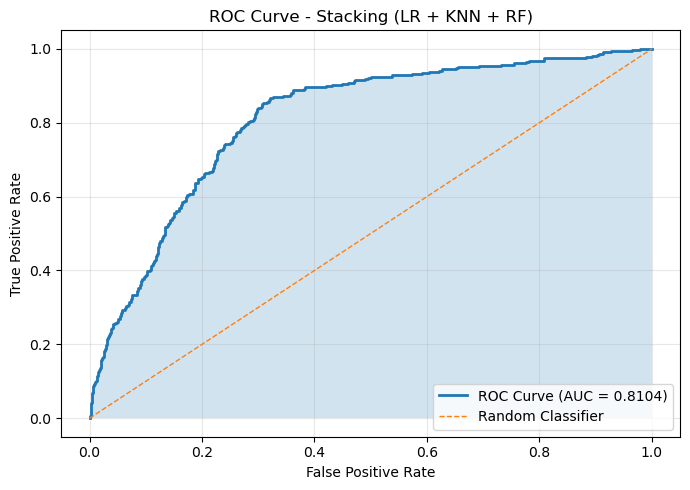

In [126]:
# Compute and plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)

    plt.figure(figsize=(7,5))
    plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {roc_auc_val:.4f})')
    plt.plot([0, 1], [0, 1], '--', linewidth=1, label='Random Classifier')
    plt.fill_between(fpr, tpr, alpha=0.2)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Stacking (LR + KNN + RF)')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("roc_stacking.png", dpi=200)
    plt.show()

    mlflow.log_artifact("roc_stacking.png")

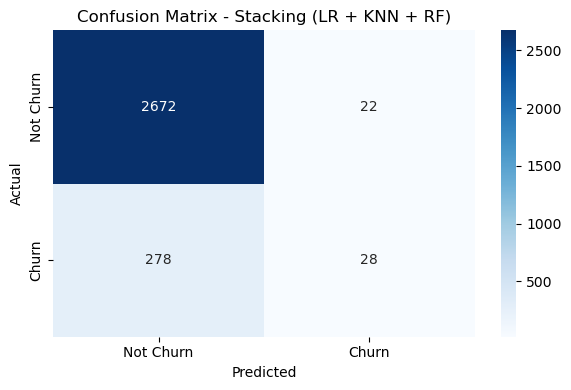

In [128]:
# Compute and plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Not Churn', 'Churn'],
                yticklabels=['Not Churn', 'Churn'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - Stacking (LR + KNN + RF)")
    plt.tight_layout()
    plt.savefig("cm_stacking.png", dpi=200)
    plt.show()

    mlflow.log_artifact("cm_stacking.png")

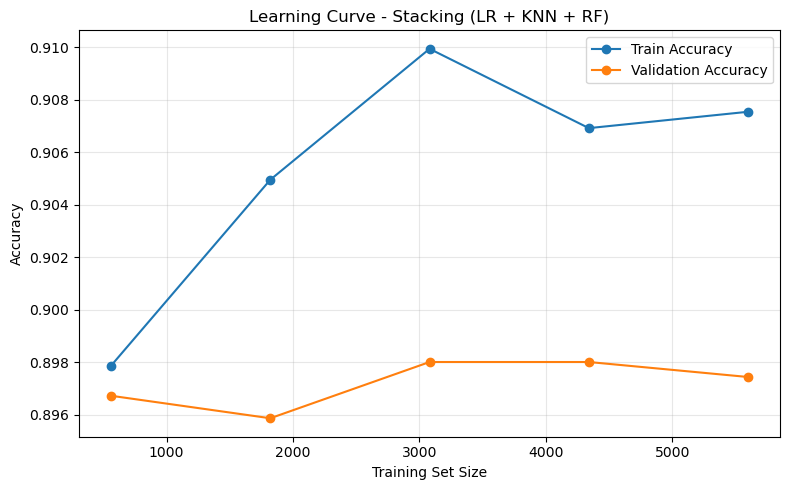

In [130]:
"""
The stacking ensemble exhibits low bias but moderate variance, as indicated by consistently
higher training accuracy compared to validation accuracy.
While stacking improves predictive performance, some sensitivity to training data remains.
"""
train_sizes, train_scores, val_scores = learning_curve(
    estimator=stack,
    X=X_train_scaled,
    y=y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train Accuracy")
plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="Validation Accuracy")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Stacking (LR + KNN + RF)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [133]:
# End the current MLflow run
mlflow.end_run()

# Comparison table between ensemble Codes

In [265]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix

def eval_ensemble(name, model, X):
    y_pred = model.predict(X)

    # AUC only if predict_proba exists
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X)[:, 1]
        auc_val = roc_auc_score(y_test, y_prob)
    else:
        auc_val = np.nan  # hard voting has no probabilities

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "ROC-AUC": auc_val,
        "Precision (Churn)": precision_score(y_test, y_pred, zero_division=0),
        "Recall (Churn)": recall_score(y_test, y_pred, zero_division=0),
        "F1 (Churn)": f1_score(y_test, y_pred, zero_division=0),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp
    }

results = [
    eval_ensemble("Hard Voting (LR+KNN+RF)", hard_vote, X_test_scaled),
    eval_ensemble("Bagging (KNN)", bag_knn, X_test_scaled[knn_features]),
    eval_ensemble("Stacking (LR+KNN+RF)", stack, X_test_scaled),
]

df_ensembles = pd.DataFrame(results)

# Sort with NaN AUC last (hard voting)
df_ensembles = df_ensembles.sort_values("ROC-AUC", ascending=False, na_position="last")

df_ensembles


,Model,Accuracy,ROC-AUC,Precision (Churn),Recall (Churn),F1 (Churn),TN,FP,FN,TP
2,Stacking (LR+KNN+RF),0.900000,0.810374,0.560000,0.091503,0.157303,2672,22,278,28
1,Bagging (KNN),0.894333,0.766652,0.351351,0.042484,0.075802,2670,24,293,13
0,Hard Voting (LR+KNN+RF),0.898333,NaN,1.000000,0.003268,0.006515,2694,0,305,1


# Imbalance 

# 1. Oversampling 

In [140]:
# Apply Random Oversampling to handle imbalance
from imblearn.over_sampling import RandomOverSampler

# 1) Initialize oversampler
overSampler = RandomOverSampler(random_state=42)

# 2) Apply ONLY on training data copy
newData_over, y_train_over = overSampler.fit_resample(newData, y_train)

# 3) Check class distribution after oversampling
pd.Series(y_train_over).value_counts()


churn
0    6285
1    6285
Name: count, dtype: int64

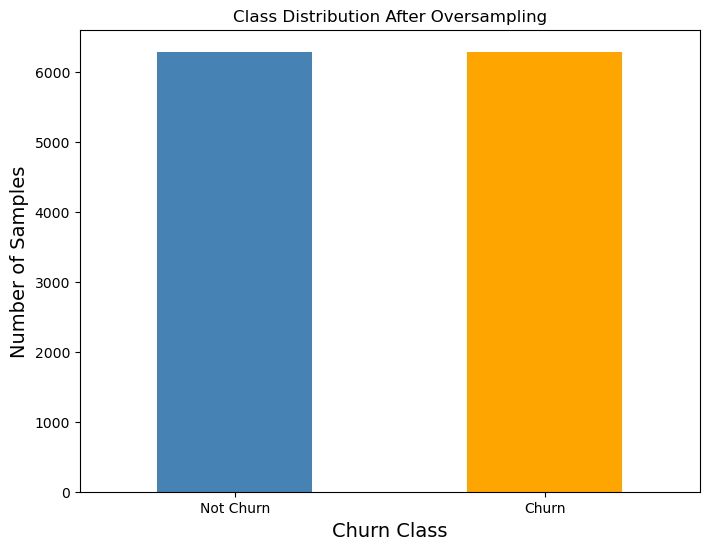

In [141]:
# Check class distribution after oversampling
# Plot class distribution AFTER oversampling
ax = pd.Series(y_train_over).value_counts().plot(
    kind='bar',
    color=['steelblue', 'orange'],
    figsize=(8, 6),
    title='Class Distribution After Oversampling'
)

ax.set_xlabel("Churn Class", fontsize=14)
ax.set_ylabel("Number of Samples", fontsize=14)

plt.xticks(
    ticks=[0, 1],
    labels=['Not Churn', 'Churn'],
    rotation=0
)

plt.show()


# 2. Undersampling

In [166]:
# =========================
# 1) Under-sample the CORRECT data (SCALED training only)
# =========================
from imblearn.under_sampling import RandomUnderSampler

underSampler = RandomUnderSampler(random_state=42)

X_train_under, y_train_under = underSampler.fit_resample(
    X_train_scaled.copy(), y_train
)

print("Class distribution after undersampling:")
print(y_train_under.value_counts())


Class distribution after undersampling:
churn
0    715
1    715
Name: count, dtype: int64


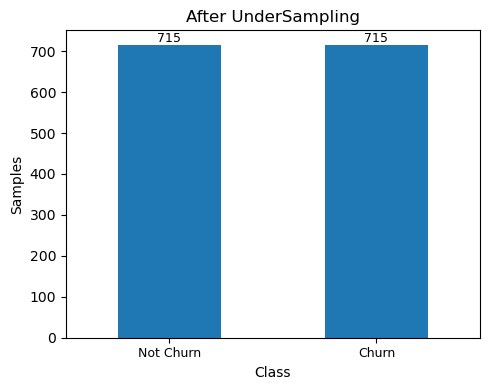

In [145]:
# Check class distribution after undersampling
# visualization AFTER undersampling
ax = pd.Series(y_train_under).value_counts().sort_index().plot(
    kind='bar',
    figsize=(5, 4),
    title='After UnderSampling'
)

ax.set_xlabel("Class", fontsize=10)
ax.set_ylabel("Samples", fontsize=10)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Not Churn', 'Churn'], fontsize=9, rotation=0)

# Add value labels (small font)
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()


# 3. SMOTE

In [170]:
# Apply SMOTE (Synthetic Minority Over-sampling Technique)
# =========================
# 1) Apply SMOTE on SCALED training data
# =========================
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=3)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled.copy(), y_train
)

print("Class distribution after SMOTE:")
print(y_train_smote.value_counts())


Class distribution after SMOTE:
churn
0    6285
1    6285
Name: count, dtype: int64


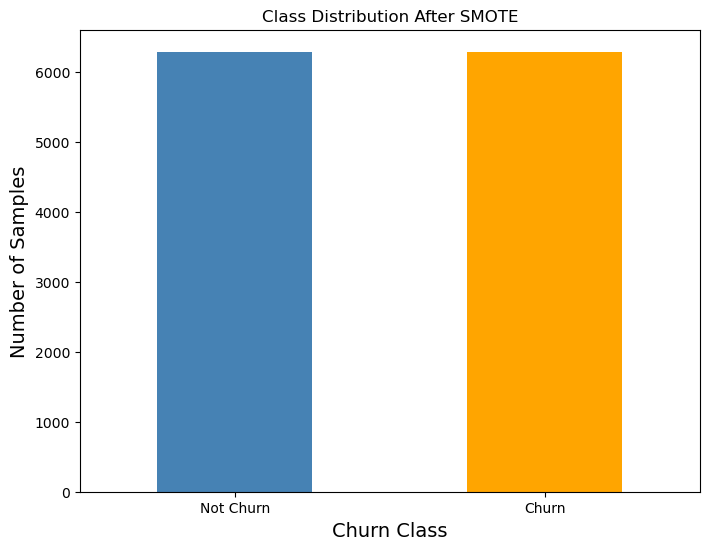

In [149]:
# Apply SMOTE (Synthetic Minority Over-sampling Technique)
# Plot class distribution AFTER oversampling
ax = pd.Series(y_train_smote).value_counts().plot(
    kind='bar',
    color=['steelblue', 'orange'],
    figsize=(8, 6),
    title='Class Distribution After SMOTE'
)

ax.set_xlabel("Churn Class", fontsize=14)
ax.set_ylabel("Number of Samples", fontsize=14)

plt.xticks(
    ticks=[0, 1],
    labels=['Not Churn', 'Churn'],
    rotation=0
)

plt.show()


# Applying 3 Imbalance Methods on best base (Stacking)

# 1. OverSampling

2025/12/20 02:15:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


=== Stacking (Oversampling - FIXED) ===
Accuracy: 0.747
AUC: 0.7843925741541358
              precision    recall  f1-score   support

           0       0.96      0.75      0.84      2694
           1       0.24      0.70      0.36       306

    accuracy                           0.75      3000
   macro avg       0.60      0.73      0.60      3000
weighted avg       0.88      0.75      0.79      3000



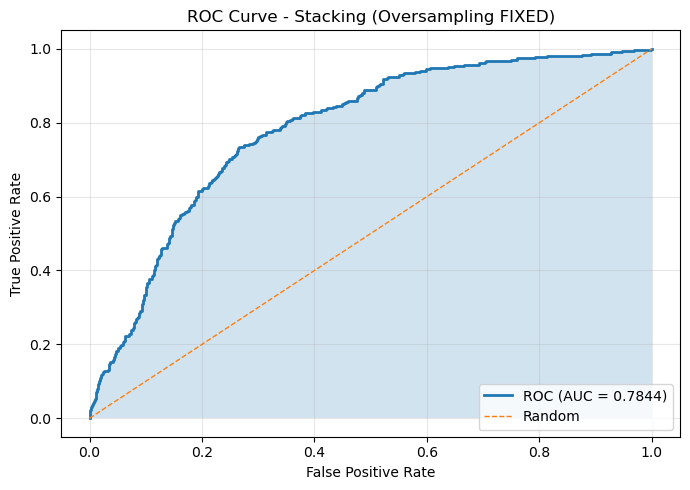

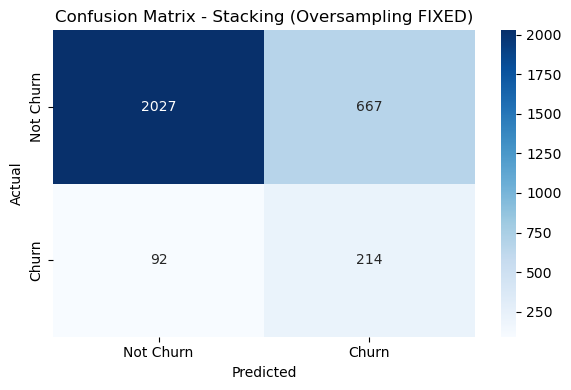

In [164]:
# Compute and plot ROC curve
# =========================
# 3) Train + Evaluate + ROC + Confusion Matrix + MLflow
# =========================
while mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(run_name="Stacking_Oversampling_FIXED"):

    stack_over = StackingClassifier(
        estimators=[("lr", lr_stack), ("knn", knn_stack), ("rf", rf_stack)],
        final_estimator=LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            C=0.5
        ),
        stack_method="predict_proba",
        passthrough=False,
        n_jobs=-1
    )

    stack_over.fit(X_train_over, y_train_over)

    y_pred = stack_over.predict(X_test_scaled)
    y_prob = stack_over.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    aucv = roc_auc_score(y_test, y_prob)

    print("=== Stacking (Oversampling - FIXED) ===")
    print("Accuracy:", acc)
    print("AUC:", aucv)
    print(classification_report(y_test, y_pred))

    # ---- MLflow logs ----
    mlflow.log_param("imbalance_method", "RandomOverSampler")
    mlflow.log_param("meta_class_weight", "balanced")
    mlflow.log_param("meta_C", 0.5)
    mlflow.log_metric("accuracy", float(acc))
    mlflow.log_metric("roc_auc", float(aucv))
    mlflow.sklearn.log_model(stack_over, "model")

    # ---- ROC Curve ----
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)

    plt.figure(figsize=(7,5))
    plt.plot(fpr, tpr, linewidth=2, label=f'ROC (AUC = {roc_auc_val:.4f})')
    plt.plot([0, 1], [0, 1], '--', linewidth=1, label='Random')
    plt.fill_between(fpr, tpr, alpha=0.2)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Stacking (Oversampling FIXED)')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("roc_stacking_over_fixed.png", dpi=200)
    plt.show()

    mlflow.log_artifact("roc_stacking_over_fixed.png")

    # ---- Confusion Matrix ----
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Not Churn', 'Churn'],
                yticklabels=['Not Churn', 'Churn'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - Stacking (Oversampling FIXED)")
    plt.tight_layout()
    plt.savefig("cm_stacking_over_fixed.png", dpi=200)
    plt.show()

    mlflow.log_artifact("cm_stacking_over_fixed.png")


C:\Users\MSI\anaconda3\envs\ml_phase2\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
2 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "C:\Users\MSI\anaconda3\envs\ml_phase2\lib\site-packages\joblib\_utils.py", line 109, in __call__
    return self.func(**kwargs)
  File "C:\Users\MSI\anaconda3\envs\ml_phase2\lib\site-packages\joblib\parallel.py", line 607, in __call__
    return [func(*args, **kwargs) for func, args, kwargs in self.items]
  File "C:\Users\MSI\anaconda3\envs\ml_phase2\lib\site-packages\joblib\parallel.py", line 60

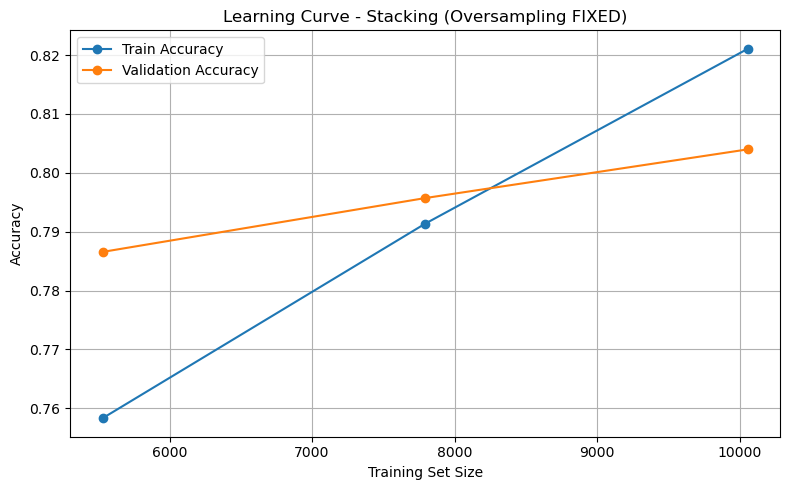

In [255]:
"""
The stacking model with oversampling shows low bias and moderate variance.
While the model learns effectively as training data increases,
the persistent gap between training and validation accuracy indicates mild overfitting, 
likely caused by the use of oversampled data
"""
# ---- Learning Curve ----
train_sizes, train_scores, val_scores = learning_curve(
    estimator=stack_over,
    X=X_train_over,          # oversampled training set
    y=y_train_over,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker="o", label="Train Accuracy")
plt.plot(train_sizes, val_mean, marker="o", label="Validation Accuracy")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Stacking (Oversampling FIXED)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("lc_stacking_over_fixed.png", dpi=200)
plt.show()

mlflow.log_artifact("lc_stacking_over_fixed.png")


# 2. UnderSampling on Stacking

2025/12/20 02:28:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


=== Stacking (UnderSampling - FIXED) ===
Accuracy: 0.7213333333333334
AUC: 0.7966371651357895
              precision    recall  f1-score   support

           0       0.97      0.71      0.82      2694
           1       0.24      0.83      0.38       306

    accuracy                           0.72      3000
   macro avg       0.61      0.77      0.60      3000
weighted avg       0.90      0.72      0.78      3000



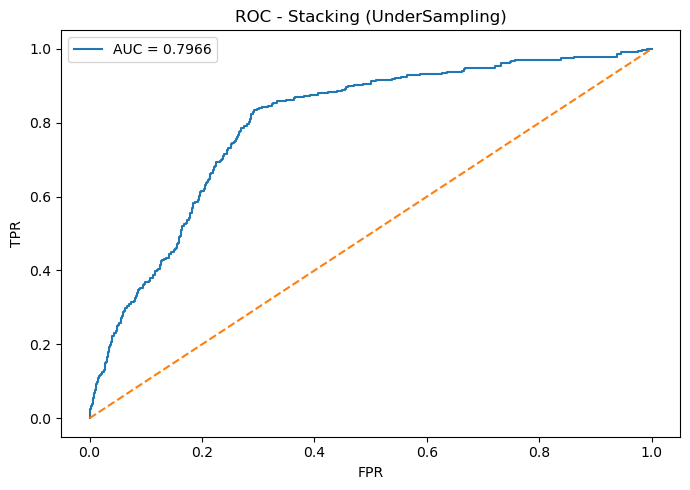

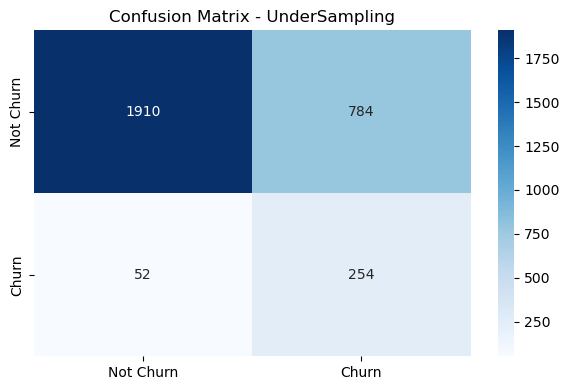

In [168]:
# Compute and plot ROC curve
# =========================
# 2) Train + Evaluate Stacking (UnderSampling)
# =========================
while mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(run_name="Stacking_UnderSampling_FIXED"):

    stack_under = StackingClassifier(
        estimators=[("lr", lr_stack), ("knn", knn_stack), ("rf", rf_stack)],
        final_estimator=LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            C=0.5
        ),
        stack_method="predict_proba",
        passthrough=False,
        n_jobs=-1
    )

    stack_under.fit(X_train_under, y_train_under)

    y_pred = stack_under.predict(X_test_scaled)
    y_prob = stack_under.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    aucv = roc_auc_score(y_test, y_prob)

    print("=== Stacking (UnderSampling - FIXED) ===")
    print("Accuracy:", acc)
    print("AUC:", aucv)
    print(classification_report(y_test, y_pred))

    mlflow.log_param("imbalance_method", "RandomUnderSampler")
    mlflow.log_metric("accuracy", float(acc))
    mlflow.log_metric("roc_auc", float(aucv))
    mlflow.sklearn.log_model(stack_under, "model")

    # ---- ROC ----
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(7,5))
    plt.plot(fpr, tpr, label=f"AUC = {aucv:.4f}")
    plt.plot([0,1],[0,1],'--')
    plt.title("ROC - Stacking (UnderSampling)")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---- Confusion Matrix ----
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Not Churn','Churn'],
                yticklabels=['Not Churn','Churn'])
    plt.title("Confusion Matrix - UnderSampling")
    plt.tight_layout()
    plt.show()


C:\Users\MSI\anaconda3\envs\ml_phase2\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
10 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "C:\Users\MSI\anaconda3\envs\ml_phase2\lib\site-packages\joblib\_utils.py", line 109, in __call__
    return self.func(**kwargs)
  File "C:\Users\MSI\anaconda3\envs\ml_phase2\lib\site-packages\joblib\parallel.py", line 607, in __call__
    return [func(*args, **kwargs) for func, args, kwargs in self.items]
  File "C:\Users\MSI\anaconda3\envs\ml_phase2\lib\site-packages\joblib\parallel.py", line 

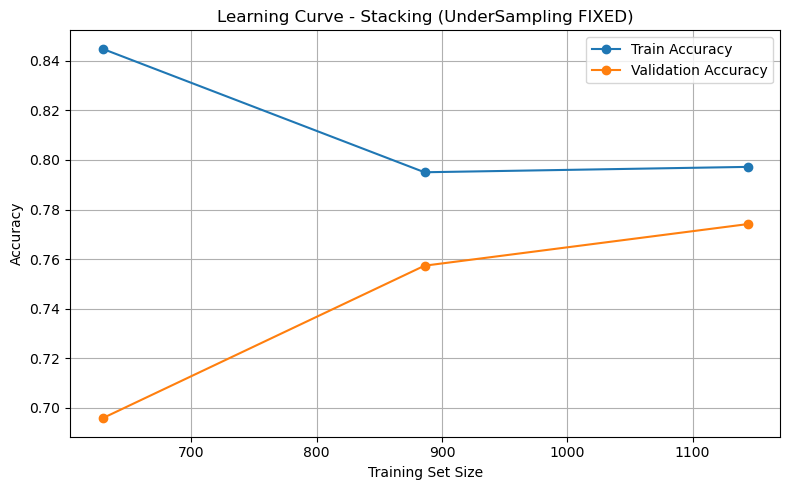

In [269]:
"""
The stacking model with undersampling shows slight
underfitting due to increased bias caused by discarding a large portion of the majority class.
"""

# ---- Learning Curve ----
train_sizes, train_scores, val_scores = learning_curve(
    estimator=stack_under,
    X=X_train_under,          # undersampled training set
    y=y_train_under,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker="o", label="Train Accuracy")
plt.plot(train_sizes, val_mean, marker="o", label="Validation Accuracy")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Stacking (UnderSampling FIXED)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("lc_stacking_under_fixed.png", dpi=200)
plt.show()

mlflow.log_artifact("lc_stacking_under_fixed.png")


# 3. SMOTE on Stacking

2025/12/20 02:29:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


=== Stacking (SMOTE - FIXED) ===
Accuracy: 0.7823333333333333
AUC: 0.7709033873386028
              precision    recall  f1-score   support

           0       0.94      0.81      0.87      2694
           1       0.25      0.57      0.35       306

    accuracy                           0.78      3000
   macro avg       0.60      0.69      0.61      3000
weighted avg       0.87      0.78      0.82      3000



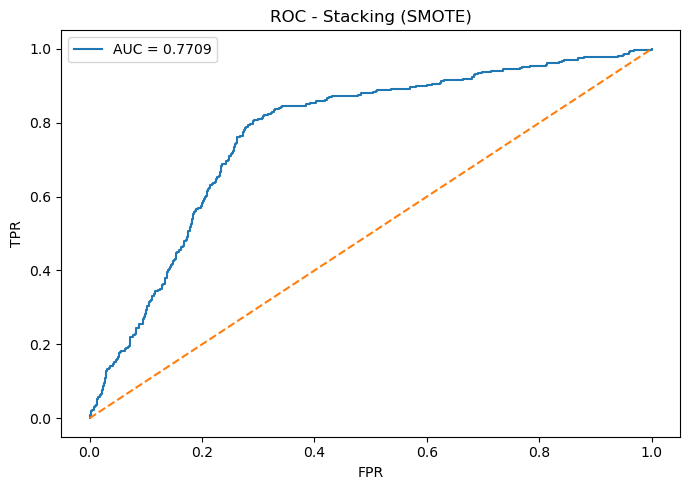

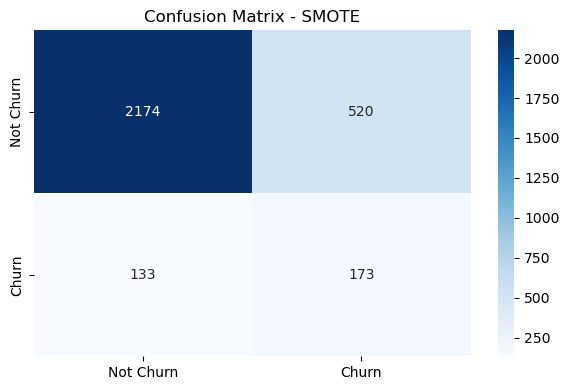

In [172]:
# Compute and plot ROC curve
# =========================
# 2) Train + Evaluate Stacking (SMOTE)
# =========================
while mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(run_name="Stacking_SMOTE_FIXED"):

    stack_smote = StackingClassifier(
        estimators=[("lr", lr_stack), ("knn", knn_stack), ("rf", rf_stack)],
        final_estimator=LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            C=0.5
        ),
        stack_method="predict_proba",
        passthrough=False,
        n_jobs=-1
    )

    stack_smote.fit(X_train_smote, y_train_smote)

    y_pred = stack_smote.predict(X_test_scaled)
    y_prob = stack_smote.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    aucv = roc_auc_score(y_test, y_prob)

    print("=== Stacking (SMOTE - FIXED) ===")
    print("Accuracy:", acc)
    print("AUC:", aucv)
    print(classification_report(y_test, y_pred))

    mlflow.log_param("imbalance_method", "SMOTE")
    mlflow.log_metric("accuracy", float(acc))
    mlflow.log_metric("roc_auc", float(aucv))
    mlflow.sklearn.log_model(stack_smote, "model")

    # ---- ROC ----
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(figsize=(7,5))
    plt.plot(fpr, tpr, label=f"AUC = {aucv:.4f}")
    plt.plot([0,1],[0,1],'--')
    plt.title("ROC - Stacking (SMOTE)")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---- Confusion Matrix ----
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Not Churn','Churn'],
                yticklabels=['Not Churn','Churn'])
    plt.title("Confusion Matrix - SMOTE")
    plt.tight_layout()
    plt.show()


C:\Users\MSI\anaconda3\envs\ml_phase2\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
2 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
joblib.externals.loky.process_executor._RemoteTraceback: 
"""
Traceback (most recent call last):
  File "C:\Users\MSI\anaconda3\envs\ml_phase2\lib\site-packages\joblib\_utils.py", line 109, in __call__
    return self.func(**kwargs)
  File "C:\Users\MSI\anaconda3\envs\ml_phase2\lib\site-packages\joblib\parallel.py", line 607, in __call__
    return [func(*args, **kwargs) for func, args, kwargs in self.items]
  File "C:\Users\MSI\anaconda3\envs\ml_phase2\lib\site-packages\joblib\parallel.py", line 60

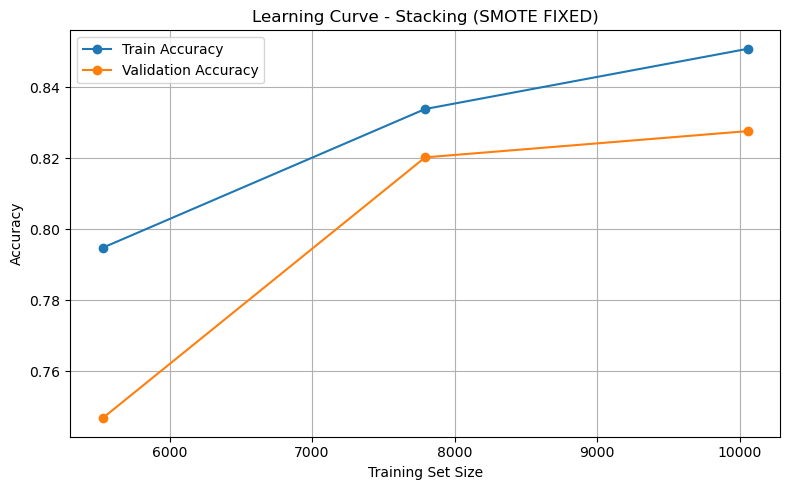

In [271]:
"""
The stacking model with SMOTE is well-fitted, 
showing low bias and mild overfitting due to the use of synthetic samples
"""

# ---- Learning Curve ----
train_sizes, train_scores, val_scores = learning_curve(
    estimator=stack_smote,
    X=X_train_smote,          # SMOTE training set
    y=y_train_smote,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker="o", label="Train Accuracy")
plt.plot(train_sizes, val_mean, marker="o", label="Validation Accuracy")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Stacking (SMOTE FIXED)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("lc_stacking_smote_fixed.png", dpi=200)
plt.show()

mlflow.log_artifact("lc_stacking_smote_fixed.png")


# Comparison of Imbalance on Stacking

In [199]:
y_pred_over  = stack_over.predict(X_test_scaled)
y_prob_over  = stack_over.predict_proba(X_test_scaled)[:, 1]

y_pred_smote = stack_smote.predict(X_test_scaled)
y_prob_smote = stack_smote.predict_proba(X_test_scaled)[:, 1]

y_pred_under = stack_under.predict(X_test_scaled)
y_prob_under = stack_under.predict_proba(X_test_scaled)[:, 1]


In [224]:
"""
The best recall and F1 is in Undersampling bec 
High recall = fewer missed churn customers & F1 = Balance between precision & recall
while the highest accuarcy is SMOTE but our target now to determine how many churns the model capture.
"""
import pandas as pd
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
)

def summarize_result(name, y_true, y_pred, y_prob):
    # churn is label 1
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    rec  = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1   = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    aucv = roc_auc_score(y_true, y_prob)

    cm = confusion_matrix(y_true, y_pred)  # [[TN, FP],[FN, TP]]
    tn, fp, fn, tp = cm.ravel()

    return {
        "Method": name,
        "Accuracy": acc,
        "Precision (Churn=1)": prec,
        "Recall (Churn=1)": rec,
        "F1 (Churn=1)": f1,
        "ROC-AUC": aucv,
        "TN": tn, "FP": fp, "FN": fn, "TP": tp
    }

results = []
results.append(summarize_result("OverSampling", y_test, y_pred_over, y_prob_over))
results.append(summarize_result("SMOTE",        y_test, y_pred_smote, y_prob_smote))
results.append(summarize_result("UnderSampling",y_test, y_pred_under, y_prob_under))

df_compare = pd.DataFrame(results).sort_values(by="F1 (Churn=1)", ascending=False)

# nicer display
display(df_compare.style.format({
    "Accuracy":"{:.3f}",
    "Precision (Churn=1)":"{:.3f}",
    "Recall (Churn=1)":"{:.3f}",
    "F1 (Churn=1)":"{:.3f}",
    "ROC-AUC":"{:.3f}",
}))


,Method,Accuracy,Precision (Churn=1),Recall (Churn=1),F1 (Churn=1),ROC-AUC,TN,FP,FN,TP
2,UnderSampling,0.721,0.245,0.830,0.378,0.797,1910,784,52,254
0,OverSampling,0.747,0.243,0.699,0.361,0.784,2027,667,92,214
1,SMOTE,0.782,0.250,0.565,0.346,0.771,2174,520,133,173


In [273]:
# End the current MLflow run
mlflow.end_run()